# Mushroom classification with tree models

Uzayr Chaudhry (uxc230006) and David Mwaria (dmm240001)

We ask which traits explain the labels, whether fewer traits retain performance, and what perfect scores actually establish. Poisonous is the positive class. All analyses below are generated by this notebook.


## Setup
`ucimlrepo` loads the data. A small scikit-learn compatible selector adds fold-local categorical association and redundancy checks. These are extensions to the lecture examples. Graphviz also requires the system `dot` program.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
import platform
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import json
import hashlib
import copy
import xgboost as xgb
from ucimlrepo import fetch_ucirepo
from sklearn.base import BaseEstimator, TransformerMixin
from joblib import parallel_backend
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score)
from IPython.display import display

SEED = 4372
np.random.seed(SEED)
FIGS, RESULTS = Path("figs"), Path("results")
FIGS.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 220})
cache = TemporaryDirectory(prefix="mushroom_cv_")

def save_figure(name):
    plt.savefig(FIGS / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

def save_table(frame, name, caption):
    frame.to_csv(RESULTS / f"{name}.csv", index=False)
    text = frame.to_latex(index=False, escape=True, float_format="%.4f",
                          caption=caption, position="H")
    text = text.replace('\\begin{table}[H]', '\\begin{table}[H]\n\\centering\\small')
    (RESULTS / f"{name}.tex").write_text(text)

versions = {p: metadata.version(p) for p in
    ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "xgboost", "graphviz", "ucimlrepo"]}
import subprocess
versions["Python"] = platform.python_version()
versions["Graphviz system"] = subprocess.run(["dot","-V"], capture_output=True, text=True, check=True).stderr.strip()
print("Python:", platform.python_version())
display(pd.Series(versions, name="Version").to_frame())

Python: 3.12.14


,Version
numpy,2.3.5
pandas,2.2.3
matplotlib,3.10.8
seaborn,0.13.2
scikit-learn,1.8.0
xgboost,3.4.1
graphviz,0.21
ucimlrepo,0.0.7
Python,3.12.14
Graphviz system,dot - graphviz version 2.43.0 (0)


## Load and audit the data
The records describe hypothetical samples associated with 23 mushroom species. Unknown edibility is grouped with poisonous. The data do not identify species, so we cannot evaluate a split by species.

The cap is the mushroom top, the gills are underneath it, and the stalk is the stem. Ring traits describe a band around the stalk. Spore print color refers to the color of deposited spores. Above-ring and below-ring traits describe different stem sections.

Source: https://archive.ics.uci.edu/dataset/73/mushroom

The importer converts missing stalk-root markers to null values. Its metadata incorrectly describes cap-color as binary; the observed values are categorical.
Most predictors are nominal. Ring number and gill size have ordered meanings, but their recorded levels are encoded as categories in the common pipeline.


In [2]:
mushroom = fetch_ucirepo(id=73)
X_raw = mushroom.data.features.copy()
y = mushroom.data.targets["poisonous"].map({"e": 0, "p": 1})
assert X_raw.shape == (8124, 22)
assert X_raw.index.equals(y.index)
assert y.notna().all()
assert set(mushroom.data.targets["poisonous"]) == {"e", "p"}

missing = X_raw.isna().sum()
audit = pd.DataFrame({"Check": ["Rows", "Predictors", "Missing cells", "Duplicate rows",
    "Duplicate predictor rows", "Edible", "Poisonous / not recommended"],
    "Count": [len(X_raw), X_raw.shape[1], int(missing.sum()),
    int(pd.concat([X_raw, y], axis=1).duplicated().sum()),
    int(X_raw.duplicated().sum()), int((y == 0).sum()), int((y == 1).sum())]})
display(audit)
display(missing[missing > 0].rename("Missing").to_frame())
save_table(audit, "data_audit", "Audit of the original Mushroom records.")

category_text = {
"cap-shape": "b:bell,c:conical,x:convex,f:flat,k:knobbed,s:sunken",
"cap-surface": "f:fibrous,g:grooves,y:scaly,s:smooth",
"cap-color": "n:brown,b:buff,c:cinnamon,g:gray,r:green,p:pink,u:purple,e:red,w:white,y:yellow",
"bruises": "t:yes,f:no",
"odor": "a:almond,l:anise,c:creosote,y:fishy,f:foul,m:musty,n:none,p:pungent,s:spicy",
"gill-attachment": "a:attached,d:descending,f:free,n:notched",
"gill-spacing": "c:close,w:crowded,d:distant",
"gill-size": "b:broad,n:narrow",
"gill-color": "k:black,n:brown,b:buff,h:chocolate,g:gray,r:green,o:orange,p:pink,u:purple,e:red,w:white,y:yellow",
"stalk-shape": "e:enlarging,t:tapering",
"stalk-root": "b:bulbous,c:club,u:cup,e:equal,z:rhizomorphs,r:rooted",
"stalk-surface-above-ring": "f:fibrous,y:scaly,k:silky,s:smooth",
"stalk-surface-below-ring": "f:fibrous,y:scaly,k:silky,s:smooth",
"stalk-color-above-ring": "n:brown,b:buff,c:cinnamon,g:gray,o:orange,p:pink,e:red,w:white,y:yellow",
"stalk-color-below-ring": "n:brown,b:buff,c:cinnamon,g:gray,o:orange,p:pink,e:red,w:white,y:yellow",
"veil-type": "p:partial,u:universal", "veil-color": "n:brown,o:orange,w:white,y:yellow",
"ring-number": "n:none,o:one,t:two",
"ring-type": "c:cobwebby,e:evanescent,f:flaring,l:large,n:none,p:pendant,s:sheathing,z:zone",
"spore-print-color": "k:black,n:brown,b:buff,h:chocolate,r:green,o:orange,u:purple,w:white,y:yellow",
"population": "a:abundant,c:clustered,n:numerous,s:scattered,v:several,y:solitary",
"habitat": "g:grasses,l:leaves,m:meadows,p:paths,u:urban,w:waste,d:woods"}
category_labels = {c: dict(v.split(":") for v in text.split(",")) for c, text in category_text.items()}
category_labels["stalk-root"]["unknown"] = "unknown"
invalid = {c: sorted(set(X_raw[c].dropna()) - set(category_labels[c])) for c in X_raw}
assert not any(invalid.values()), invalid
print("Unexpected category codes: 0")
assert X_raw.isna().sum().sum() == 2480
assert X_raw.isna().sum().loc["stalk-root"] == 2480
fingerprint = hashlib.sha256(pd.util.hash_pandas_object(
    pd.concat([X_raw, y], axis=1), index=True).values.tobytes()).hexdigest()
assert fingerprint == "264de1e992340debe1459beac18c9c57c465a396f0d52bad101268f25ebab2ca", "Source or hashing version changed; review the analysis."
(RESULTS / "data_fingerprint.txt").write_text(fingerprint + "\n")
variables = pd.DataFrame({"Attribute": X_raw.columns,
    "Known levels": X_raw.nunique().values,
    "Missing": X_raw.isna().sum().values})
variables.to_csv(RESULTS / "dataset_variables.csv", index=False)
variable_table = variables.rename(columns={"Known levels": "Levels"})
(RESULTS / "dataset_variables.tex").write_text(variable_table.to_latex(
    index=False, escape=True, longtable=True,
    caption="Known category counts and missing values in all records."))
display(variables)
category_dictionary = pd.DataFrame([{"Attribute": c, "Code": k, "Meaning": v}
    for c, entries in category_labels.items() for k, v in entries.items()])
category_dictionary.to_csv(RESULTS / "category_dictionary.csv", index=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Training: {len(X_train):,}; test: {len(X_test):,}")

Unexpected category codes: 0
Training: 6,499; test: 1,625


,Check,Count
0,Rows,8124
1,Predictors,22
2,Missing cells,2480
3,Duplicate rows,0
4,Duplicate predictor rows,0
5,Edible,4208
6,Poisonous / not recommended,3916


,Missing
stalk-root,2480


,Attribute,Known levels,Missing
0,cap-shape,6,0
1,cap-surface,4,0
2,cap-color,10,0
3,bruises,2,0
4,odor,9,0
5,gill-attachment,2,0
6,gill-spacing,2,0
7,gill-size,2,0
8,gill-color,12,0
9,stalk-shape,2,0


## Examine the training data
We reserve the test set before target-based exploration. Missing stalk-root values remain as an explicit unknown category rather than deleting records. Frequency plots describe categorical variables; normality tests on letter codes would have no useful meaning.

,Attribute,Levels,Missing,Most common
0,cap-shape,6,0,x
1,cap-surface,4,0,y
2,cap-color,10,0,n
3,bruises,2,0,f
4,odor,9,0,n
5,gill-attachment,2,0,f
6,gill-spacing,2,0,c
7,gill-size,2,0,b
8,gill-color,12,0,b
9,stalk-shape,2,0,t


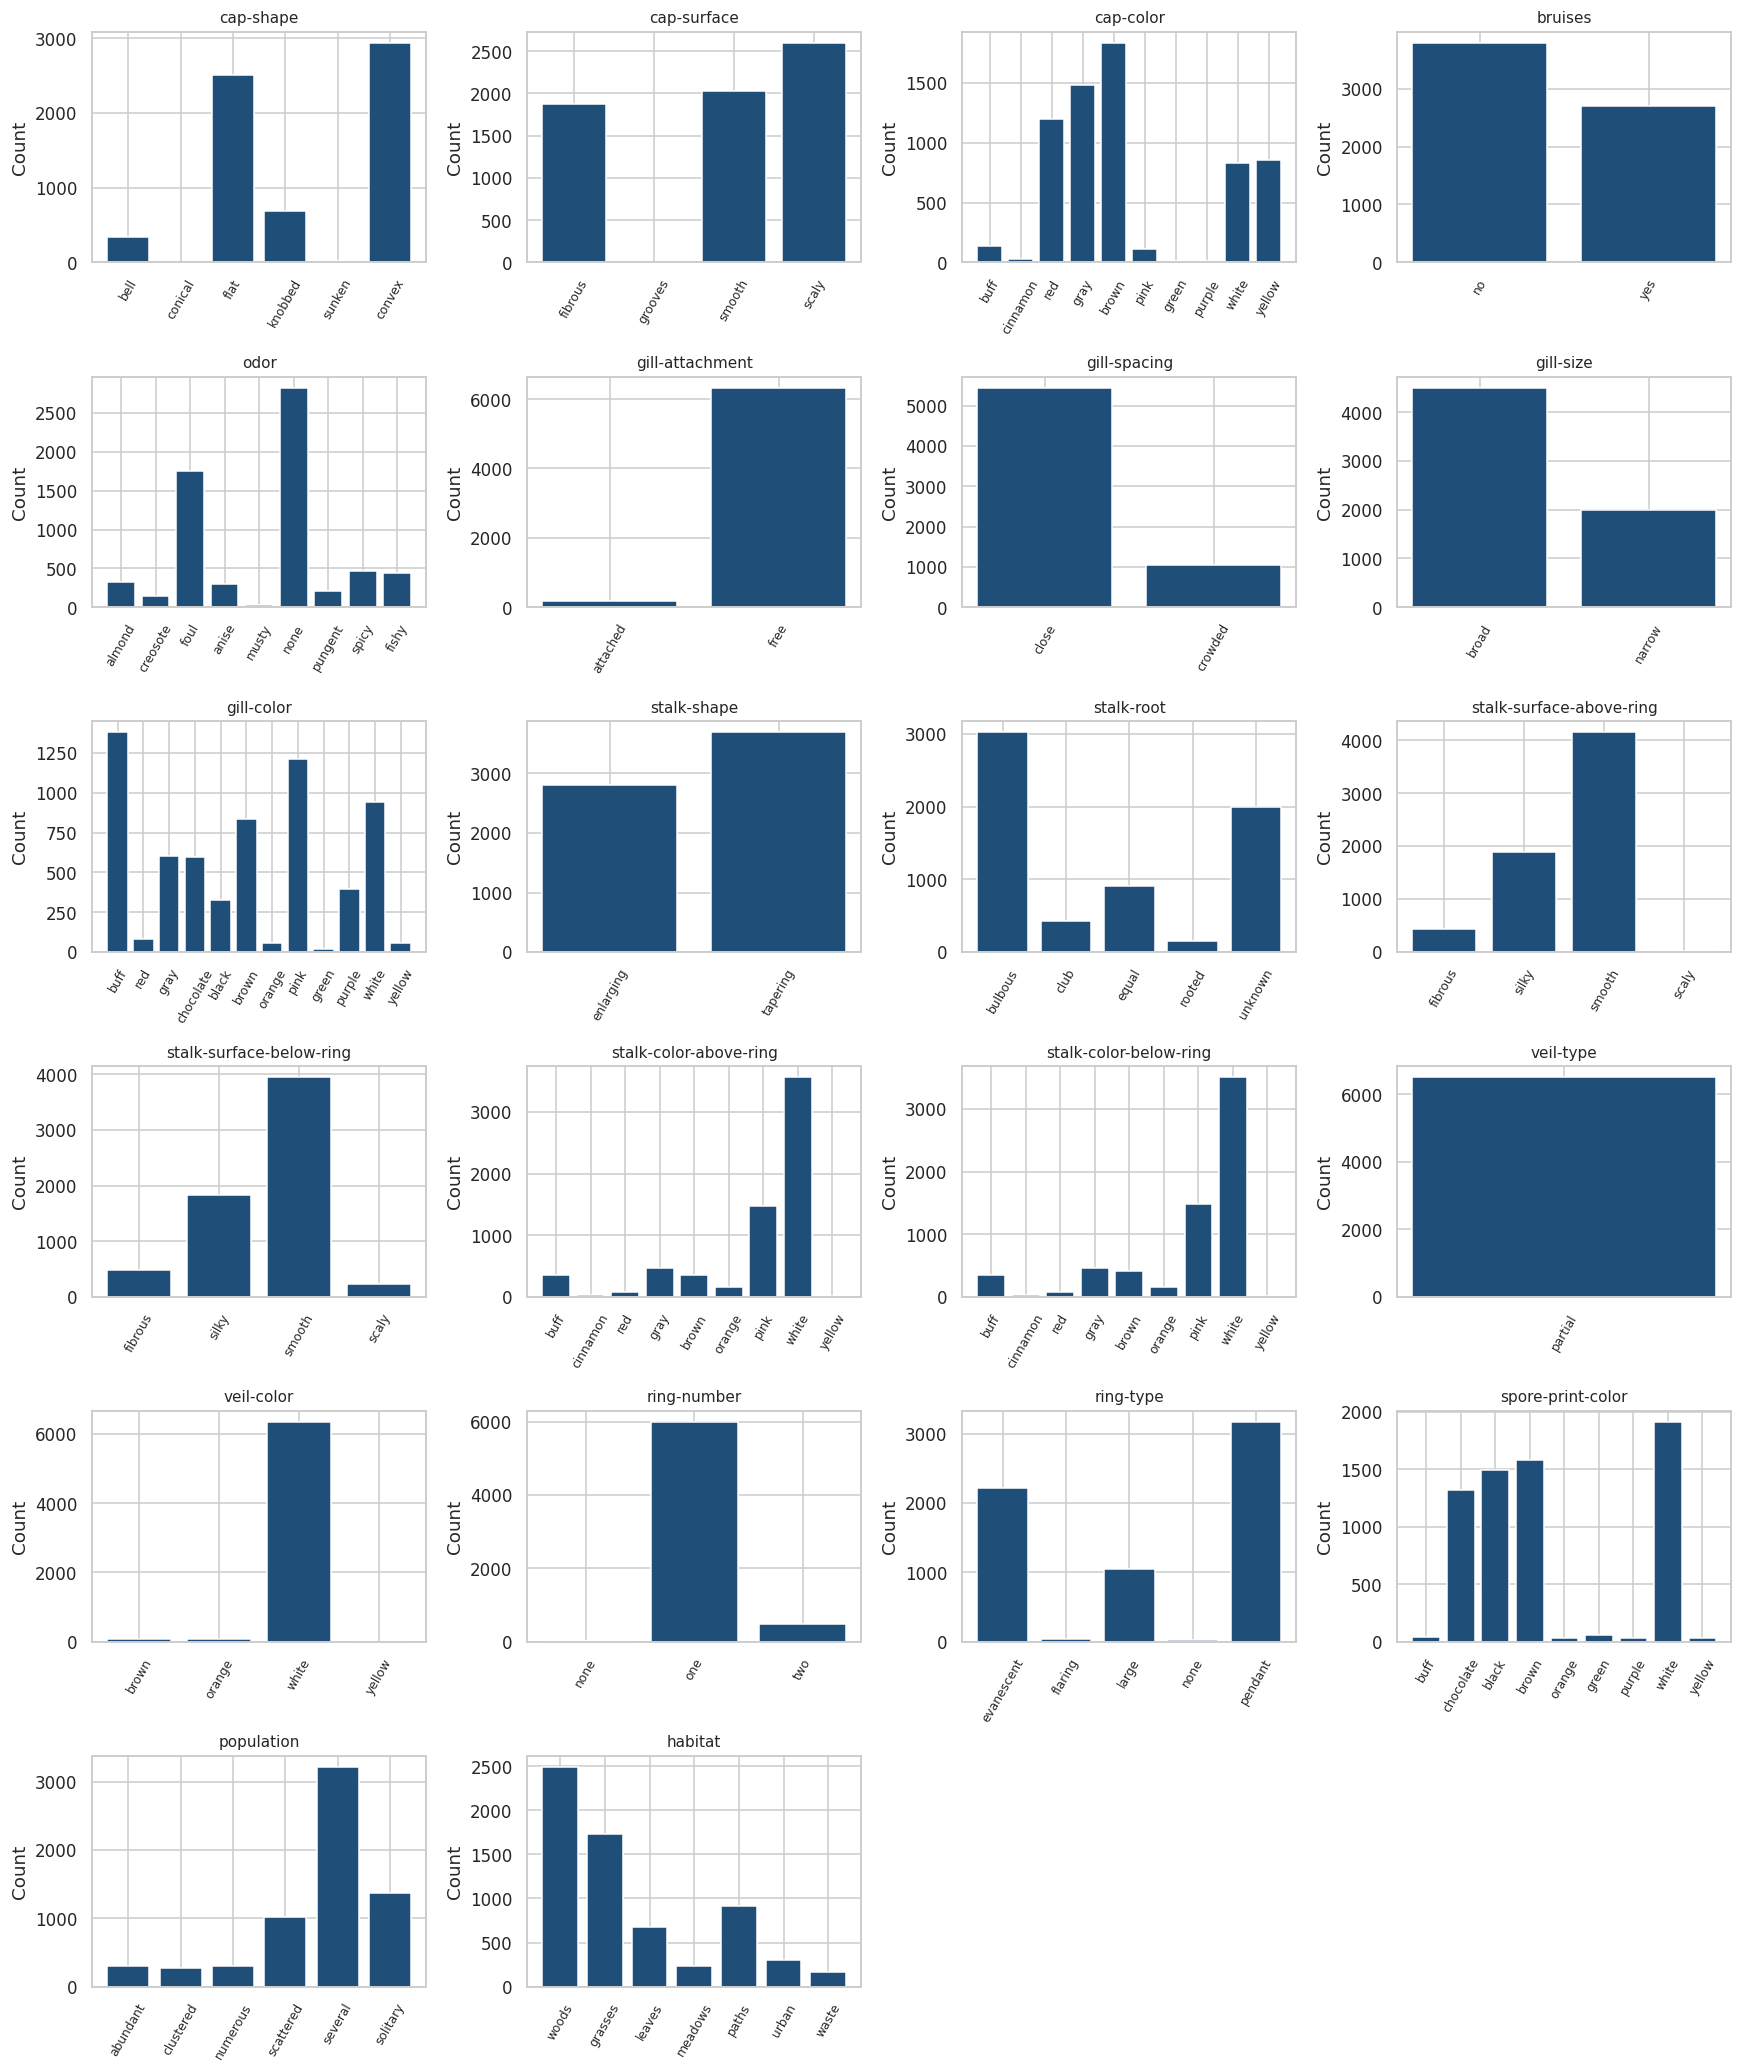

Poisonous,0,1
Root missing,,
False,2778,1731
True,588,1402


Poisonous,0,1
Odor,,
a,328,0
c,0,146
f,0,1750
l,304,0
m,0,24
n,2734,94
p,0,208
s,0,465
y,0,446


,Category,Count,Attribute
4,s,24,cap-shape
5,c,4,cap-shape
9,g,4,cap-surface
18,r,14,cap-color
19,u,13,cap-color
30,m,24,odor
48,r,17,gill-color
59,y,22,stalk-surface-above-ring
71,c,24,stalk-color-above-ring
72,y,7,stalk-color-above-ring


In [3]:
train_view = X_train.fillna("unknown")
summary = pd.DataFrame({"Attribute": X_train.columns,
    "Levels": train_view.nunique().values,
    "Missing": X_train.isna().sum().values,
    "Most common": train_view.mode().iloc[0].values})
display(summary)
summary.to_csv(RESULTS / "attribute_summary.csv", index=False)
frequencies = pd.concat([train_view[c].value_counts().rename_axis("Category")
    .reset_index(name="Count").assign(Attribute=c) for c in train_view], ignore_index=True)
frequencies.to_csv(RESULTS / "category_frequencies.csv", index=False)
fig, axes = plt.subplots(6, 4, figsize=(16, 19))
for ax, c in zip(axes.flat, train_view):
    counts = train_view[c].value_counts().sort_index()
    ax.bar([category_labels[c][k] for k in counts.index], counts.values, color="#1F4E79")
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.set_title(c, fontsize=10)
    ax.set_ylabel("Count")
for ax in axes.flat[22:]: ax.set_visible(False)
plt.tight_layout()
save_figure("01_category_distributions")
display(pd.crosstab(X_train["stalk-root"].isna(), y_train,
                   rownames=["Root missing"], colnames=["Poisonous"]))
display(pd.crosstab(X_train["odor"], y_train,
                   rownames=["Odor"], colnames=["Poisonous"]))
missing_summary = pd.crosstab(X_train["stalk-root"].isna(), y_train).rename(columns={0:"Edible", 1:"Poisonous"})
missing_summary["Poisonous fraction"] = missing_summary["Poisonous"] / missing_summary[["Edible", "Poisonous"]].sum(axis=1)
missing_summary.reset_index().to_csv(RESULTS / "missingness_by_class.csv", index=False)
odor_summary = pd.crosstab(X_train["odor"].map(category_labels["odor"]), y_train).rename(columns={0:"Edible",1:"Poisonous"})
odor_summary.reset_index().to_csv(RESULTS / "odor_by_class.csv", index=False)
rare = frequencies.loc[frequencies["Count"] < 25].copy()
display(rare)


In [4]:
print(f"Missing stalk-root: {X_raw['stalk-root'].isna().sum():,} records ({X_raw['stalk-root'].isna().mean():.2%}).")
print("Missingness and class on training rows:")
display(missing_summary)
print("Odor and class on training rows:")
display(odor_summary)
print("Rare levels deserve caution because their support is small.")
print("All original predictors are categorical, so their nonnormality reflects discrete categories rather than a failed model assumption.")

Missing stalk-root: 2,480 records (30.53%).
Missingness and class on training rows:
Odor and class on training rows:
Rare levels deserve caution because their support is small.
All original predictors are categorical, so their nonnormality reflects discrete categories rather than a failed model assumption.


poisonous,Edible,Poisonous,Poisonous fraction
stalk-root,,,
False,2778,1731,0.383899
True,588,1402,0.704523


poisonous,Edible,Poisonous
odor,,
almond,328,0
anise,304,0
creosote,0,146
fishy,0,446
foul,0,1750
musty,0,24
none,2734,94
pungent,0,208
spicy,0,465


## Measure categorical associations
Cramér's V measures association without assigning an order to category codes. Zero indicates no association; one indicates the maximum association under this measure. It is descriptive, not causal. Unequal category counts and rare levels can affect its interpretation.

,Cramers V
odor,0.971595
spore-print-color,0.752560
gill-color,0.677551
ring-type,0.601857
stalk-surface-above-ring,0.586004
stalk-surface-below-ring,0.575617
gill-size,0.541484
stalk-color-above-ring,0.524714
stalk-color-below-ring,0.519560
bruises,0.497549


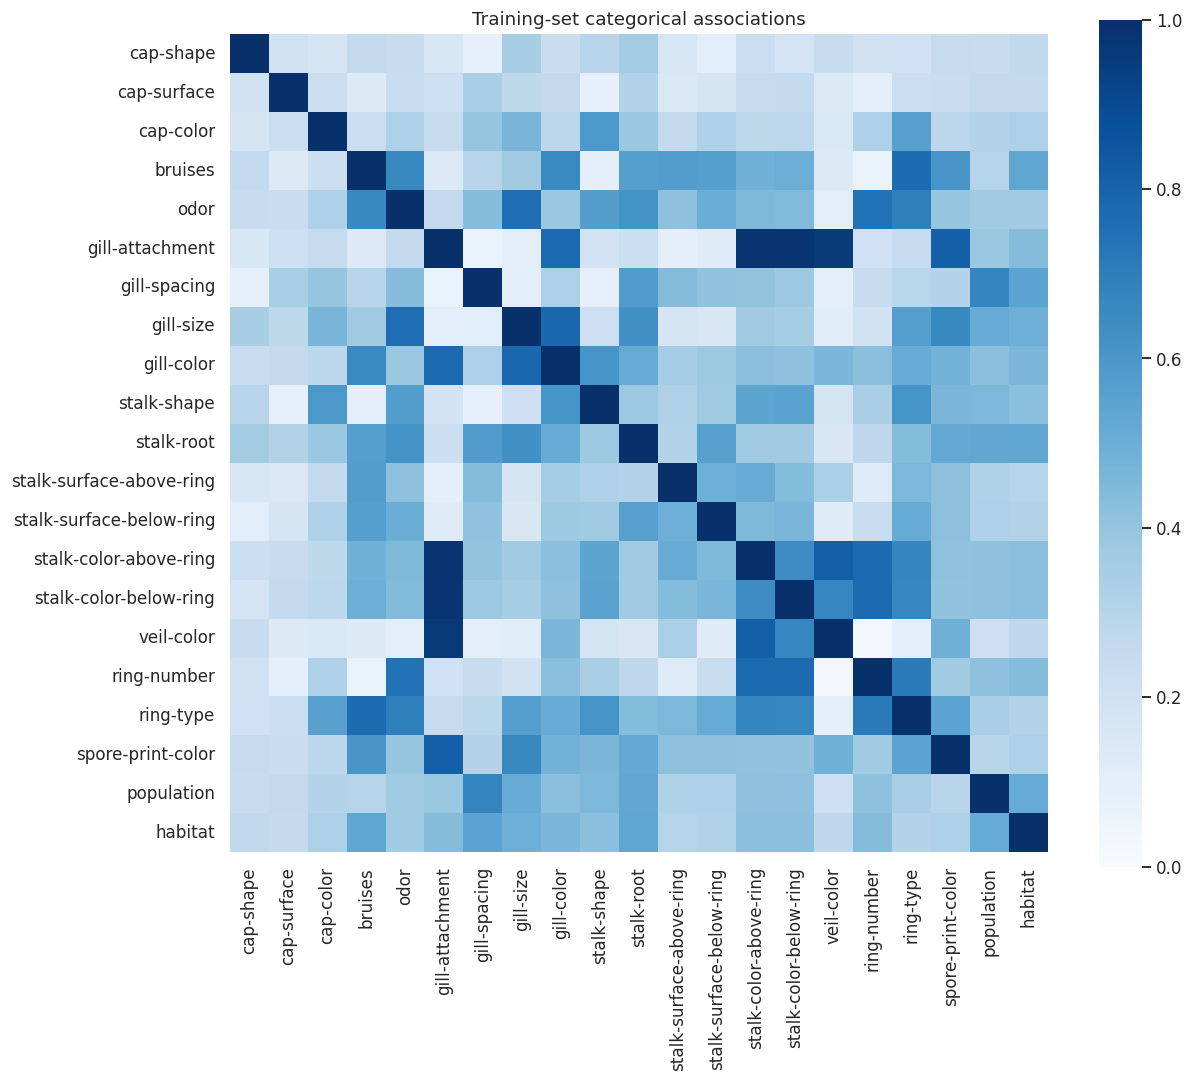

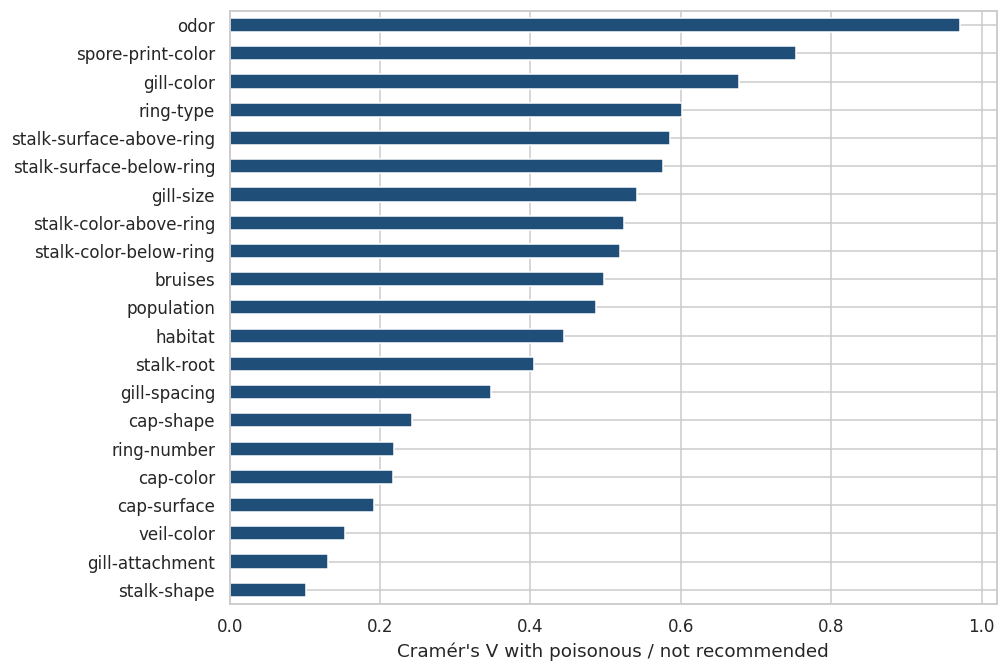

In [5]:
def cramers_v(a, b):
    table = pd.crosstab(a, b).to_numpy(dtype=float)
    n = table.sum()
    degrees = min(table.shape) - 1
    if degrees == 0:
        return np.nan
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / n
    chi_square = ((table - expected) ** 2 / expected).sum()
    return float(np.sqrt(chi_square / (n * degrees)))

association = pd.DataFrame(index=train_view.drop(columns="veil-type").columns, columns=train_view.drop(columns="veil-type").columns, dtype=float)
for a in association.index:
    for b in association.columns:
        association.loc[a, b] = cramers_v(train_view[a], train_view[b])
target_association = pd.Series({c: cramers_v(train_view[c], y_train.to_numpy())
    for c in association.index}, name="Cramers V").sort_values(ascending=False)
display(target_association.to_frame())
association.to_csv(RESULTS / "attribute_associations.csv")
target_association.to_csv(RESULTS / "target_associations.csv")
plt.figure(figsize=(12, 10))
sns.heatmap(association, vmin=0, vmax=1, cmap="Blues", square=True)
plt.title("Training-set categorical associations")
save_figure("02_association_heatmap")
plt.figure(figsize=(9, 7))
target_association.sort_values().plot.barh(color="#1F4E79")
plt.xlabel("Cramér's V with poisonous / not recommended")
save_figure("03_target_associations")

## Encode and scale inside each fold
One-hot encoding avoids artificial category order. Constant features are removed. We demonstrate both standardization and min-max normalization using training-fit transformations. Min-max scaling leaves nonconstant binary indicators unchanged. Standardization does not make them normal.

The model pipelines use one-hot encoding and min-max normalization. These trees do not need standardized inputs to compare feature thresholds.

In [6]:
encoder_demo = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoded_train = encoder_demo.fit_transform(train_view.drop(columns="veil-type"))
encoded_test = encoder_demo.transform(X_test.drop(columns="veil-type").fillna("unknown"))
standardizer, normalizer = StandardScaler(), MinMaxScaler()
standardized_train = standardizer.fit_transform(encoded_train)
normalized_train = normalizer.fit_transform(encoded_train)
standardized_test = standardizer.transform(encoded_test)
normalized_test = normalizer.transform(encoded_test)
print("Encoded training shape:", encoded_train.shape)
print("Largest absolute standardized mean:", np.abs(standardized_train.mean(axis=0)).max())
print("Min-max training range:", normalized_train.min(), normalized_train.max())
scaling_rows = []
for partition, arrays in [("Train", [encoded_train, standardized_train, normalized_train]),
                          ("Test", [encoded_test, standardized_test, normalized_test])]:
    for representation, array in zip(["Encoded", "Standardized", "Min-max"], arrays):
        scaling_rows.append({"Partition": partition, "Representation": representation,
            "Rows": array.shape[0], "Columns": array.shape[1],
            "Minimum": float(array.min()), "Maximum": float(array.max()),
            "Largest absolute column mean": float(np.abs(array.mean(axis=0)).max()),
            "Smallest column SD": float(array.std(axis=0).min()),
            "Largest column SD": float(array.std(axis=0).max())})
scaling_summary = pd.DataFrame(scaling_rows)
scaling_summary.to_csv(RESULTS / "scaling_summary.csv", index=False)
display(scaling_summary)


Encoded training shape: (6499, 116)
Largest absolute standardized mean: 3.2061341323534296e-15
Min-max training range: 0.0 1.0


,Partition,Representation,Rows,Columns,Minimum,Maximum,Largest absolute column mean,Smallest column SD,Largest column SD
0,Train,Encoded,6499,116,0.00000,1.000000,9.752270e-01,2.480122e-02,0.499975
1,Train,Standardized,6499,116,-6.27427,40.295781,3.206134e-15,1.000000e+00,1.000000
2,Train,Min-max,6499,116,0.00000,1.000000,9.752270e-01,2.480122e-02,0.499975
3,Test,Encoded,1625,116,0.00000,1.000000,9.760000e-01,0.000000e+00,0.499958
4,Test,Standardized,1625,116,-6.27427,30.453712,7.076359e-02,4.440892e-16,1.411482
5,Test,Min-max,1625,116,0.00000,1.000000,9.760000e-01,0.000000e+00,0.499958


## Feature policies and model selection

Ranking uses training-fold Cramer's V with the target. A second policy skips pairs with V above 0.90. This is a redundancy screen, not a causal test. We compare prefixes of 6, 7, 8, 9, 10 and 21 attributes.

Earlier development identified gill color and upper stalk surface as jointly removable from the seven-attribute prefix. We now compare that five-attribute policy and each of its five single-attribute removals in the same training-only grid. Named exclusions are applied to the ranked prefix, then the result is capped at the prefix size minus the number excluded. This keeps the five- or four-attribute limit when rankings change. Every fold refits ranking, encoding and scaling. These candidates extend earlier training exploration and are compared using training folds. The same test set was evaluated in earlier project versions and is retained for comparison. Final feature policies and hyperparameters are selected using training cross-validation.

Mean validation F1 selects the winner. Exact ties prefer fewer original attributes, no pairwise screen, shallower trees, fewer estimators, larger minimum leaves and lower learning rate, in that order. This is a stated preference among searched settings, not proof of global minimum complexity.


In [7]:
class AttributeSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=21, prune=False, drop=()):
        self.k = k
        self.prune = prune
        self.drop = drop

    def fit(self, X, y):
        data = X.fillna("unknown")
        candidates = [c for c in data if data[c].nunique() > 1]
        scores = {c: cramers_v(data[c], np.asarray(y)) for c in candidates}
        ranked = sorted(candidates, key=lambda c: (-scores[c], c))
        selected = []
        for c in ranked:
            if self.prune and any(cramers_v(data[c], data[s]) > 0.90 for s in selected):
                continue
            selected.append(c)
            if len(selected) == self.k:
                break
        self.selected_ = [c for c in selected if c not in self.drop][:max(1, self.k - len(self.drop))]
        return self

    def transform(self, X):
        return X[self.selected_].fillna("unknown")

def make_pipeline(model, k=21, prune=False):
    return Pipeline([
        ("select", AttributeSelector(k=k, prune=prune)),
        ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ("scale", MinMaxScaler()),
        ("model", model)
    ], memory=cache.name)

scores = {"f1": "f1", "recall": "recall", "accuracy": "accuracy", "roc_auc": "roc_auc"}
searches = {}

def choose_candidate(results):
    mean = np.asarray(results["mean_test_f1"])
    tied = np.flatnonzero(np.isclose(mean, mean.max(), rtol=0, atol=1e-12))
    def simplicity(i):
        params = results["params"][i]
        return (params.get("select__k", 21) - len(params.get("select__drop", ())), params.get("select__prune", False),
            params.get("model__max_depth") or 999,
            params.get("model__estimator__max_depth", 0),
            params.get("model__n_estimators", 1),
            -params.get("model__min_samples_leaf", 1),
            params.get("model__learning_rate", 0),
            str(params))
    return int(min(tied, key=simplicity))

def fit_search(name, pipeline, grid):
    search = GridSearchCV(pipeline, grid, scoring=scores, refit=choose_candidate, cv=cv,
                          n_jobs=4, return_train_score=True, error_score="raise")
    with parallel_backend("threading"):
        search.fit(X_train, y_train)
    searches[name] = search
    pd.DataFrame(search.cv_results_).to_csv(RESULTS / f"{name.lower().replace(' ', '_')}_grid.csv", index=False)
    print(name, "best CV F1:", round(search.cv_results_["mean_test_f1"][search.best_index_], 5))
    print(search.best_params_)
    return search

reduced_drop = ("gill-color", "stalk-surface-above-ring")
five_attributes = ["odor", "spore-print-color", "ring-type", "stalk-surface-below-ring", "gill-size"]
# These development-stage candidates are assessed with training folds only.
drop_policies = [reduced_drop] + [reduced_drop + (c,) for c in five_attributes]
def expanded_grid(base):
    reduced = {k: v for k, v in base.items() if not k.startswith("select__")}
    reduced.update({"select__k": [7], "select__prune": [False], "select__drop": drop_policies})
    return [base, reduced]

dt_search = fit_search("Decision Tree", make_pipeline(DecisionTreeClassifier(random_state=SEED)), expanded_grid({
    "select__k": [6, 7, 8, 9, 10, 21], "select__prune": [False, True],
    "model__max_depth": [3, 6, None], "model__min_samples_leaf": [1, 5]}))
print("Selected attributes:", dt_search.best_estimator_.named_steps["select"].selected_)



Decision Tree best CV F1: 1.0
{'model__max_depth': 6, 'model__min_samples_leaf': 5, 'select__drop': ('gill-color', 'stalk-surface-above-ring'), 'select__k': 7, 'select__prune': False}
Selected attributes: ['odor', 'spore-print-color', 'ring-type', 'stalk-surface-below-ring', 'gill-size']


## Tune the ensembles
All searches use the same five folds and maximize positive-class F1. Recall, accuracy, and ROC AUC are retained for context. The grids are finite comparisons, not proof of a global optimum. Complete candidate results are exported.

Random Forest best CV F1: 1.0
{'model__max_depth': 6, 'model__max_features': 0.7, 'model__min_samples_leaf': 3, 'model__n_estimators': 100, 'select__drop': ('gill-color', 'stalk-surface-above-ring'), 'select__k': 7, 'select__prune': False}
AdaBoost best CV F1: 1.0
{'model__estimator__max_depth': 1, 'model__learning_rate': 1.0, 'model__n_estimators': 150, 'select__drop': ('gill-color', 'stalk-surface-above-ring'), 'select__k': 7, 'select__prune': False}
XGBoost best CV F1: 1.0
{'model__learning_rate': 0.2, 'model__max_depth': 2, 'model__n_estimators': 250, 'select__drop': ('gill-color', 'stalk-surface-above-ring'), 'select__k': 7, 'select__prune': False}
Decision Tree selected settings: {'model__max_depth': 6, 'model__min_samples_leaf': 5, 'select__drop': ('gill-color', 'stalk-surface-above-ring'), 'select__k': 7, 'select__prune': False}
Random Forest selected settings: {'model__max_depth': 6, 'model__max_features': 0.7, 'model__min_samples_leaf': 3, 'model__n_estimators': 100, 'select_

,Model,Candidates,CV F1,CV SD,Attributes
0,Decision Tree,108,1.0,0.0,5
1,Random Forest,288,1.0,0.0,5
2,AdaBoost,216,1.0,0.0,5
3,XGBoost,144,1.0,0.0,5


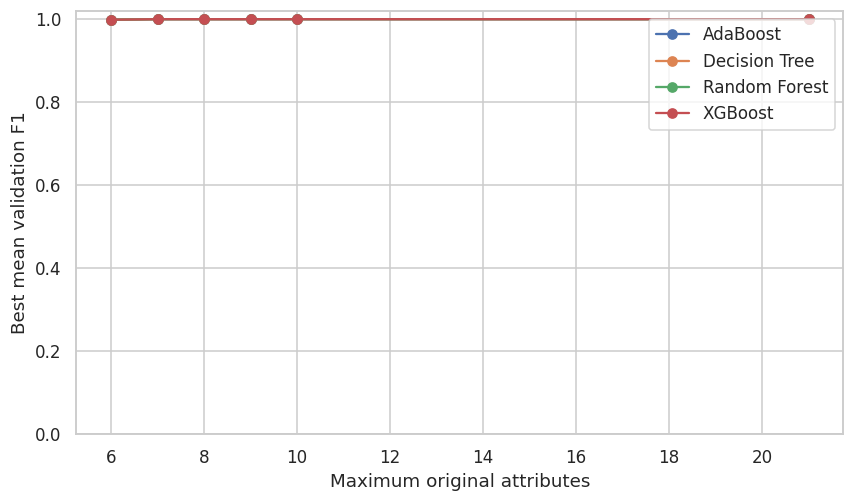

In [8]:
rf_search = fit_search("Random Forest", make_pipeline(
    RandomForestClassifier(random_state=SEED, n_jobs=1)), expanded_grid({
    "select__k": [6, 7, 8, 9, 10, 21], "select__prune": [False, True],
    "model__n_estimators": [100, 250], "model__max_depth": [6, None],
    "model__min_samples_leaf": [1, 3], "model__max_features": ["sqrt", 0.7]}))
ada_search = fit_search("AdaBoost", make_pipeline(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
                       random_state=SEED)), expanded_grid({
    "select__k": [6, 7, 8, 9, 10, 21], "select__prune": [False, True],
    "model__n_estimators": [50, 150], "model__learning_rate": [0.1, 0.5, 1.0],
    "model__estimator__max_depth": [1, 2]}))
xgb_search = fit_search("XGBoost", make_pipeline(
    xgb.XGBClassifier(random_state=SEED, n_jobs=1, tree_method="hist", eval_metric="logloss"),
    ), expanded_grid({
    "select__k": [6, 7, 8, 9, 10, 21], "select__prune": [False, True],
    "model__max_depth": [2, 4], "model__n_estimators": [100, 250],
    "model__learning_rate": [0.05, 0.2]}))

tuning_summary = pd.DataFrame([{"Model": name, "Candidates": len(s.cv_results_["params"]),
    "CV F1": s.cv_results_["mean_test_f1"][s.best_index_], "CV SD": s.cv_results_["std_test_f1"][s.best_index_],
    "Attributes": len(s.best_estimator_.named_steps["select"].selected_)}
    for name, s in searches.items()])
save_table(tuning_summary, "tuning_summary", "Selected cross-validation results.")
display(tuning_summary)
for name, search in searches.items():
    print(name, "selected settings:", search.best_params_)
selected_policies = []
for name, search in searches.items():
    pipe = search.best_estimator_
    params = search.best_params_
    selected_policies.append({"Model": name, "Attributes": pipe.named_steps["select"].selected_, "Parameters": params})
(RESULTS / "selected_models.json").write_text(json.dumps(selected_policies, indent=2))
selection_summary = pd.concat([pd.DataFrame(s.cv_results_).loc[lambda d: d["param_select__drop"].isna()].groupby(
    ["param_select__k", "param_select__prune"], as_index=False)["mean_test_f1"].max().assign(Model=name)
    for name, s in searches.items()], ignore_index=True)
selection_summary.columns = ["Maximum attributes", "Pruning", "Best CV F1", "Model"]
save_table(selection_summary, "feature_selection_summary", "Best validation F1 by feature policy and model.")
(RESULTS / "feature_selection_summary.tex").write_text(selection_summary.to_latex(
    index=False, escape=True, longtable=True, float_format="%.4f",
    caption="Best validation F1 by feature policy and model."))
fig, ax = plt.subplots(figsize=(9, 5))
for name, group in selection_summary.query("Pruning == False").groupby("Model"):
    ax.plot(group["Maximum attributes"], group["Best CV F1"], marker="o", label=name)
ax.set(xlabel="Maximum original attributes", ylabel="Best mean validation F1", ylim=(0,1.02))
ax.legend()
save_figure("04_feature_selection")


## Visualize the selected trees
The decision tree is shown to depth three for readability. Ensemble figures show one representative tree, not the complete voting or boosting process. Split labels refer to encoded categories.

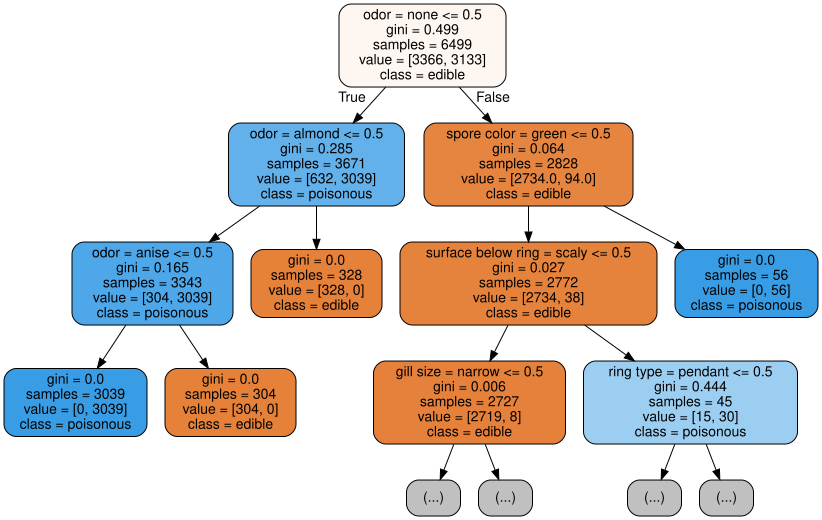

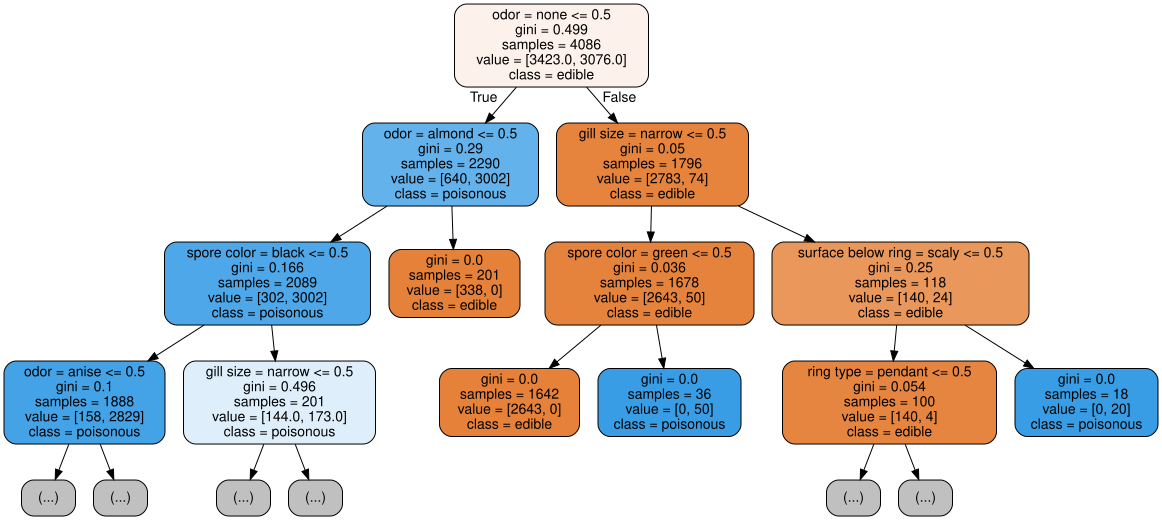

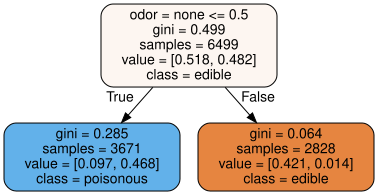

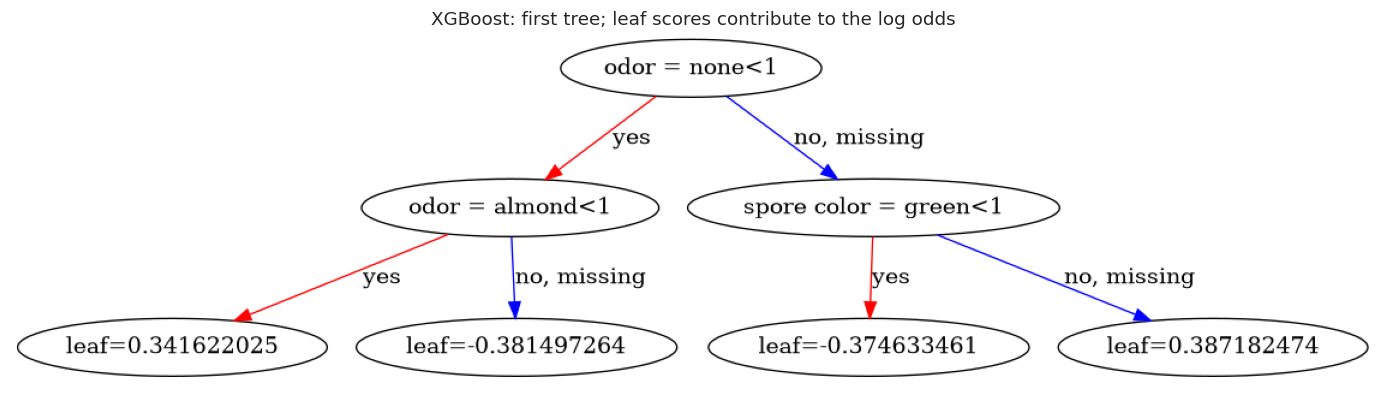

In [9]:
for name, search in searches.items():
    pipe = search.best_estimator_
    encoded_names = pipe.named_steps["encode"].get_feature_names_out()
    names = []
    for item in encoded_names:
        attribute, category = item.rsplit("_", 1)
        short = attribute.replace("stalk-surface", "surface").replace("stalk-color", "stalk color").replace("spore-print-color", "spore color")
        names.append(short.replace("-", " ") + " = " + category_labels[attribute][category])
    pd.DataFrame({"Index": np.arange(len(names)), "Encoded": encoded_names, "Meaning": names}).to_csv(
        RESULTS / f"{name.lower().replace(' ', '_')}_feature_names.csv", index=False)
    model = pipe.named_steps["model"]
    if name == "XGBoost":
        fig, ax = plt.subplots(figsize=(16, 9))
        booster = copy.deepcopy(model.get_booster())
        booster.feature_names = names
        xgb.plot_tree(booster, tree_idx=0, ax=ax)
        ax.set_title("XGBoost: first tree; leaf scores contribute to the log odds")
        save_figure("08_xgboost_tree")
        continue
    tree = model if name == "Decision Tree" else model.estimators_[0]
    dot = export_graphviz(tree, out_file=None, feature_names=names,
        class_names=["edible", "poisonous"], max_depth=3, filled=True, rounded=True)
    number = {"Decision Tree": "05_decision_tree", "Random Forest": "06_random_forest_tree",
              "AdaBoost": "07_adaboost_tree"}[name]
    graph = graphviz.Source(dot)
    graph.render(filename=number, directory=str(FIGS), format="pdf", cleanup=True)
    display(graph)
pipe = searches["Decision Tree"].best_estimator_
full_dot = export_graphviz(pipe.named_steps["model"], out_file=None,
    feature_names=pd.read_csv(RESULTS / "decision_tree_feature_names.csv")["Meaning"].tolist(),
    class_names=["edible", "poisonous"], filled=True, rounded=True)
graphviz.Source(full_dot).render(filename="05_decision_tree_full", directory=str(FIGS), format="pdf", cleanup=True)
complexity = []
for name, search in searches.items():
    model = search.best_estimator_.named_steps["model"]
    if name == "Decision Tree":
        count, depth, leaves = 1, model.get_depth(), model.get_n_leaves()
    elif name == "XGBoost":
        count = model.get_booster().num_boosted_rounds()
        def tree_size(node, level=0):
            children = node.get("children", [])
            if not children:
                return level, 1
            sizes = [tree_size(child, level + 1) for child in children]
            return max(d for d, _ in sizes), sum(n for _, n in sizes)
        sizes = [tree_size(json.loads(t)) for t in model.get_booster().get_dump(dump_format="json")]
        depth = max(d for d, _ in sizes)
        leaves = sum(n for _, n in sizes)
    else:
        count = len(model.estimators_)
        depth = max(t.get_depth() for t in model.estimators_)
        leaves = sum(t.get_n_leaves() for t in model.estimators_)
    complexity.append({"Model": name, "Trees": count, "Max fitted depth": depth, "Total leaves": leaves})
pd.DataFrame(complexity).to_csv(RESULTS / "model_complexity.csv", index=False)


## Conditional feature removal

A large marginal association does not establish that a trait adds information after other traits are known. We remove each attribute from the winning Decision Tree policy with its settings fixed and refit the complete pipeline in every fold. These are conditional diagnostics, not a fresh feature search.


,Removed attribute,CV F1,CV SD
0,None,1.000000,0.000000
1,odor,0.979836,0.002964
2,spore-print-color,0.989675,0.002211
3,ring-type,0.998720,0.000961
4,stalk-surface-below-ring,0.994396,0.001682
5,gill-size,0.998720,0.000961


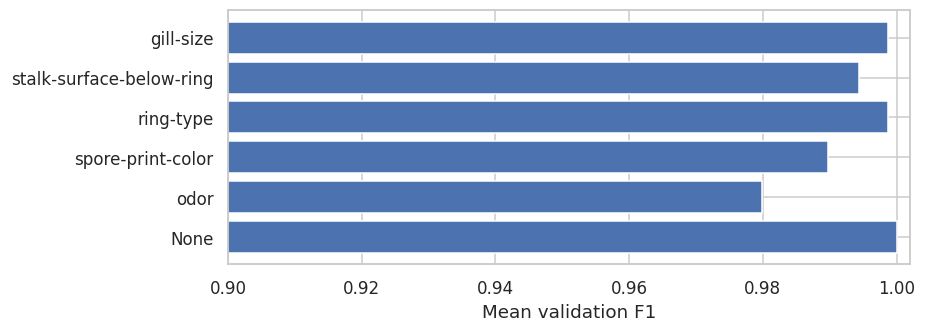

In [10]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate, StratifiedGroupKFold
from sklearn.metrics import brier_score_loss, log_loss
best_dt = dt_search.best_estimator_
selected_dt = best_dt.named_steps["select"].selected_
base_drop = tuple(best_dt.named_steps["select"].drop)
removal_rows = []
for removed in [None] + selected_dt:
    pipe = clone(best_dt).set_params(select__drop=base_drop + (() if removed is None else (removed,)))
    fold_scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring="f1", error_score="raise")
    removal_rows.append({"Removed attribute": removed or "None", "CV F1": fold_scores["test_score"].mean(),
                         "CV SD": fold_scores["test_score"].std()})
removal = pd.DataFrame(removal_rows)
save_table(removal, "conditional_removal", "Removal from the selected Decision Tree policy, with model settings fixed.")
display(removal)
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(removal["Removed attribute"], removal["CV F1"])
ax.set(xlabel="Mean validation F1", xlim=(0.9, 1.002))
save_figure("12_conditional_removal")


## Evaluate the previously evaluated test set
A false negative is a poisonous or not-recommended record predicted edible. ROC and precision-recall curves use positive-class probabilities. Average precision summarizes the precision-recall relationship; it is not the trapezoidal area under that curve.

We include an always-edible baseline. It predicts the training majority class and gives every record the training poisonous proportion as its probability.

In [11]:
predictions, probabilities, metric_rows = {}, {}, []
for name, search in searches.items():
    pipe = search.best_estimator_
    predictions[name] = pipe.predict(X_test)
    probabilities[name] = pipe.predict_proba(X_test)[:, list(pipe.classes_).index(1)]
majority_label = int(y_train.mean() >= 0.5)
predictions["Majority baseline"] = np.full(len(y_test), majority_label, dtype=int)
probabilities["Majority baseline"] = np.full(len(y_test), y_train.mean())
for name in predictions:
    pred, prob = predictions[name], probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, prob)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    metric_rows.append({"Model": name, "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
        "ROC AUC": auc(fpr, tpr), "Average precision": average_precision_score(y_test, prob),
        "False negatives": fn, "False positives": fp})
metrics = pd.DataFrame(metric_rows)
save_table(metrics.drop(columns=["False negatives", "False positives"]), "test_metrics", "Classification metrics on the previously evaluated test set.")
metrics.to_csv(RESULTS / "test_metrics_with_errors.csv", index=False)
display(metrics)
export = pd.DataFrame({"Original row": X_test.index, "Actual": y_test.to_numpy()})
for name in predictions:
    export[f"{name} prediction"] = predictions[name]
    export[f"{name} probability"] = probabilities[name]
export.to_csv(RESULTS / "test_predictions.csv", index=False)
for name in searches:
    print(name)
    print(classification_report(y_test, predictions[name], target_names=["edible", "poisonous"], digits=4))
    report_dict = classification_report(y_test, predictions[name], target_names=["edible", "poisonous"], output_dict=True)
    accuracy = report_dict.pop("accuracy")
    class_report = pd.DataFrame(report_dict).T
    class_report.loc["accuracy", :] = [np.nan, np.nan, accuracy, len(y_test)]
    class_report.to_csv(RESULTS / f"{name.lower().replace(' ', '_')}_classification_report.csv")

Decision Tree
              precision    recall  f1-score   support

      edible     1.0000    1.0000    1.0000       842
   poisonous     1.0000    1.0000    1.0000       783

    accuracy                         1.0000      1625
   macro avg     1.0000    1.0000    1.0000      1625
weighted avg     1.0000    1.0000    1.0000      1625

Random Forest
              precision    recall  f1-score   support

      edible     1.0000    1.0000    1.0000       842
   poisonous     1.0000    1.0000    1.0000       783

    accuracy                         1.0000      1625
   macro avg     1.0000    1.0000    1.0000      1625
weighted avg     1.0000    1.0000    1.0000      1625

AdaBoost
              precision    recall  f1-score   support

      edible     1.0000    1.0000    1.0000       842
   poisonous     1.0000    1.0000    1.0000       783

    accuracy                         1.0000      1625
   macro avg     1.0000    1.0000    1.0000      1625
weighted avg     1.0000    1.0000    

,Model,Accuracy,Precision,Recall,F1,ROC AUC,Average precision,False negatives,False positives
0,Decision Tree,1.000000,1.0,1.0,1.0,1.0,1.000000,0,0
1,Random Forest,1.000000,1.0,1.0,1.0,1.0,1.000000,0,0
2,AdaBoost,1.000000,1.0,1.0,1.0,1.0,1.000000,0,0
3,XGBoost,1.000000,1.0,1.0,1.0,1.0,1.000000,0,0
4,Majority baseline,0.518154,0.0,0.0,0.0,0.5,0.481846,783,0


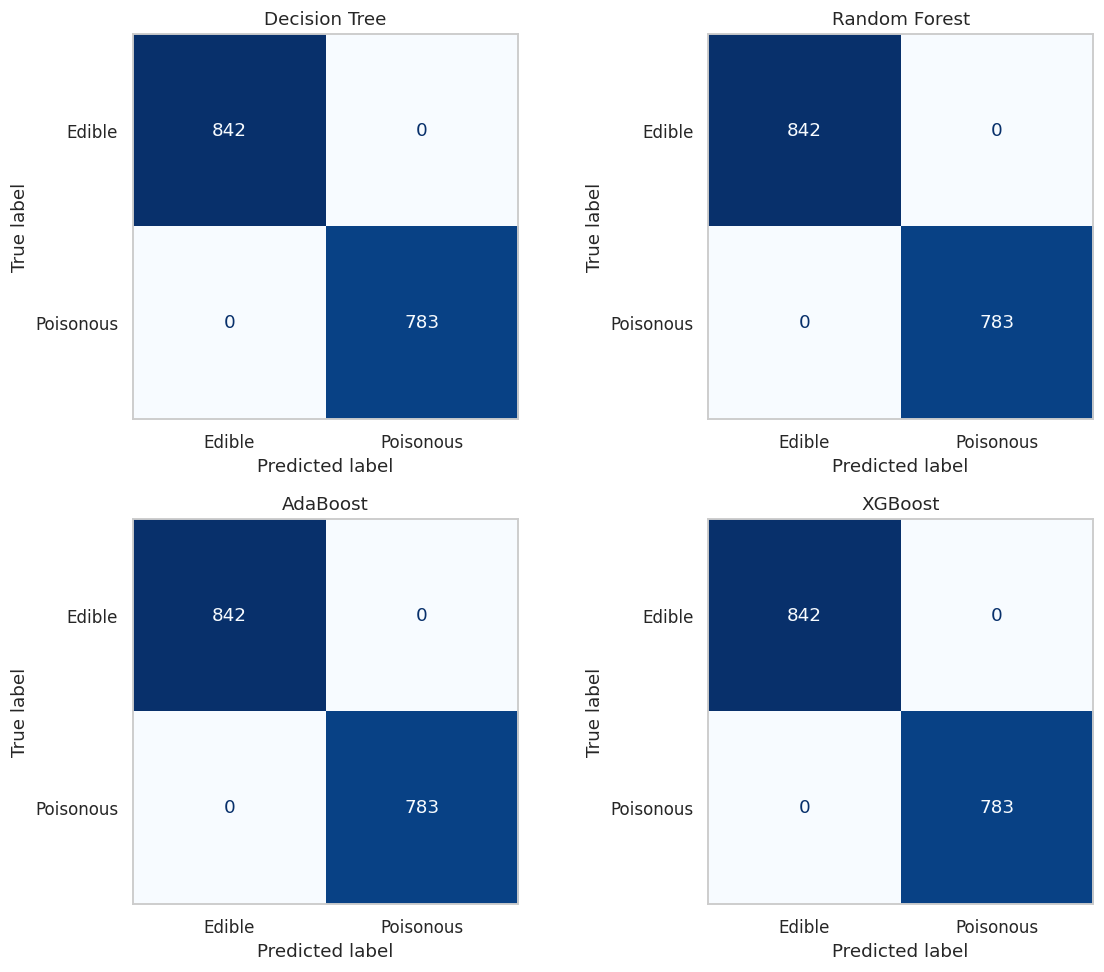

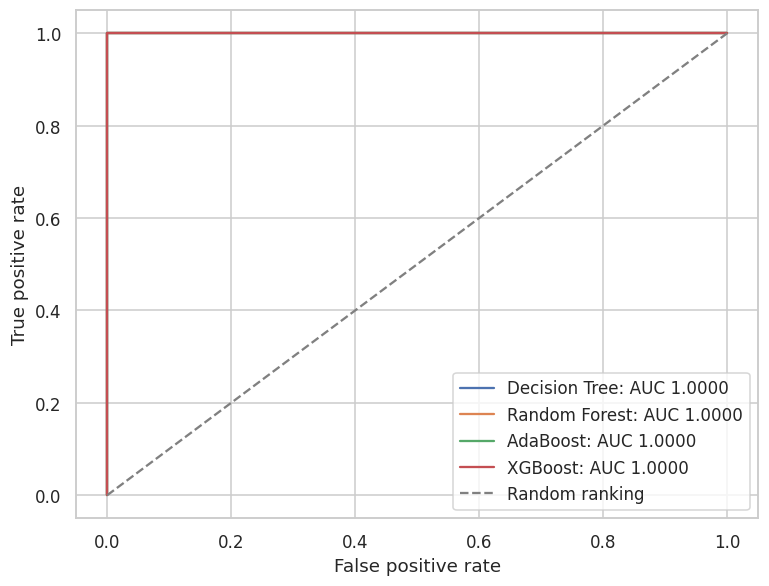

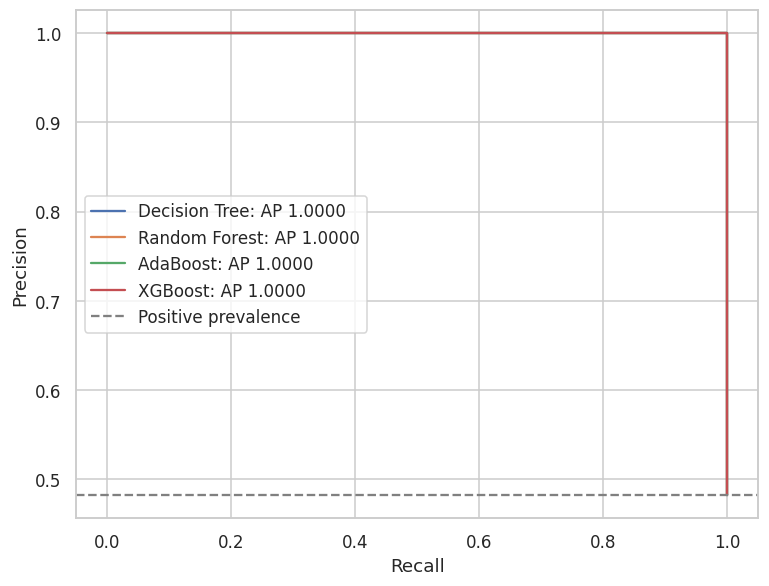

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.flat, searches):
    ConfusionMatrixDisplay(confusion_matrix(y_test, predictions[name], labels=[0, 1]),
        display_labels=["Edible", "Poisonous"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
save_figure("09_confusion_matrices")
plt.figure(figsize=(8, 6))
for name in searches:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name}: AUC {auc(fpr, tpr):.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
save_figure("10_roc_curves")
plt.figure(figsize=(8, 6))
for name in searches:
    precision, recall, _ = precision_recall_curve(y_test, probabilities[name])
    plt.plot(recall, precision, label=f"{name}: AP {average_precision_score(y_test, probabilities[name]):.4f}")
plt.axhline(y_test.mean(), ls="--", color="gray", label="Positive prevalence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
save_figure("11_precision_recall_curves")

## Baselines, probability quality and profile coverage

An edible-only classifier is a useful accuracy baseline, but its positive-class F1 is zero. An all-poisonous baseline gives a fairer reference for F1. An odor-only rule learned from training category majorities tests how much work the remaining traits do.

Brier score and log loss assess probability quality. Perfect labels and perfect ranking can coexist with weak probabilities. Reliability bins show observed frequencies and their support; they do not prove calibration outside this dataset.


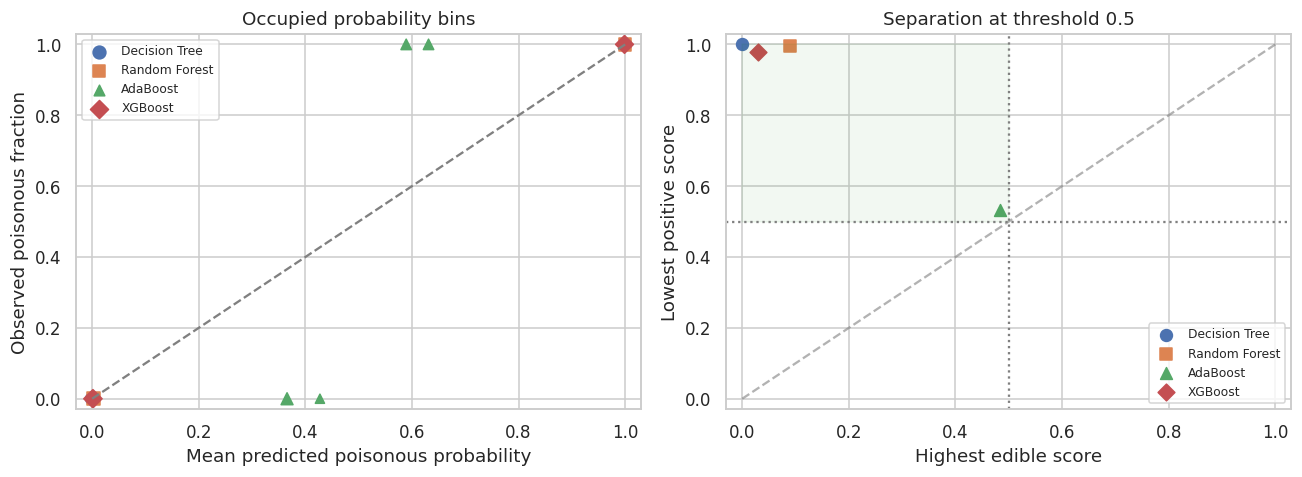

,Baseline,Accuracy,Precision,Recall,F1,FN,FP
0,Always edible,0.518154,0.000000,0.000000,0.000000,783,0
1,Always poisonous,0.481846,0.481846,1.000000,0.650332,0,842
2,Odor category majority,0.984000,1.000000,0.966794,0.983117,26,0


,Model,Brier,Log loss,Maximum edible score,Minimum poisonous score
0,Decision Tree,0.000000,2.220446e-16,0.000000,1.000000
1,Random Forest,0.000056,1.375681e-03,0.090560,0.994697
2,AdaBoost,0.149355,4.875533e-01,0.483501,0.531352
3,XGBoost,0.000020,1.435162e-03,0.028798,0.978898


,Policy,Attributes,Training profiles,Test profiles,Test rows seen in training,Training mixed-label profiles
0,All original attributes,22,6499,1625,0,0
1,Seven-attribute prefix,7,174,171,1625,0
2,Selected Decision Tree,5,47,46,1625,0


In [13]:
baseline_rows = []
odor_rates = pd.DataFrame({"odor": X_train["odor"], "target": y_train}).groupby("odor").target.mean()
odor_probability = X_test["odor"].map(odor_rates).fillna(y_train.mean()).to_numpy()
for name, prediction in [("Always edible", np.zeros(len(y_test), dtype=int)),
                         ("Always poisonous", np.ones(len(y_test), dtype=int)),
                         ("Odor category majority", (odor_probability >= 0.5).astype(int))]:
    tn, fp, fn, tp = confusion_matrix(y_test, prediction).ravel()
    baseline_rows.append({"Baseline": name, "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction, zero_division=0),
        "Recall": recall_score(y_test, prediction, zero_division=0), "F1": f1_score(y_test, prediction),
        "FN": fn, "FP": fp})
baselines = pd.DataFrame(baseline_rows)
save_table(baselines, "baselines", "Predefined test-set baselines; positive class is poisonous.")
probability_rows, bins = [], []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
markers = dict(zip(searches, ["o", "s", "^", "D"]))
for name, search in searches.items():
    probability = search.best_estimator_.predict_proba(X_test)[:, 1]
    probability_rows.append({"Model": name, "Brier": brier_score_loss(y_test, probability),
        "Log loss": log_loss(y_test, probability),
        "Maximum edible score": probability[y_test.to_numpy() == 0].max(),
        "Minimum poisonous score": probability[y_test.to_numpy() == 1].min()})
    bin_index = np.minimum((probability * 10).astype(int), 9)
    points = []
    for b in range(10):
        mask = bin_index == b
        if mask.any():
            row = {"Model": name, "Bin": b, "Count": int(mask.sum()),
                "Mean probability": float(probability[mask].mean()),
                "Observed fraction": float(y_test.to_numpy()[mask].mean())}
            bins.append(row); points.append(row)
    points = pd.DataFrame(points)
    axes[0].scatter(points["Mean probability"], points["Observed fraction"],
                    s=25 + 90 * points["Count"] / len(y_test), marker=markers[name], label=name)
    axes[1].scatter(probability_rows[-1]["Maximum edible score"],
                    probability_rows[-1]["Minimum poisonous score"], marker=markers[name], s=60, label=name)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set(title="Occupied probability bins", xlabel="Mean predicted poisonous probability",
            ylabel="Observed poisonous fraction", xlim=(-.03,1.03), ylim=(-.03,1.03))
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=.6)
axes[1].axvline(.5, linestyle=":", color="gray")
axes[1].axhline(.5, linestyle=":", color="gray")
axes[1].fill_between([0, .5], .5, 1, color="green", alpha=.05)
axes[1].set(title="Separation at threshold 0.5", xlabel="Highest edible score",
            ylabel="Lowest positive score", xlim=(-.03,1.03), ylim=(-.03,1.03))
axes[0].legend(fontsize=8, loc="upper left"); axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
save_figure("13_probability_quality")
probability_quality = pd.DataFrame(probability_rows)
save_table(probability_quality, "probability_quality", "Probability quality on the previously evaluated test set; smaller losses are better.")
pd.DataFrame(bins).to_csv(RESULTS / "reliability_bins.csv", index=False)
display(baselines); display(probability_quality)
coverage_rows = []
for name, attributes in [("All original attributes", list(X_raw)), ("Seven-attribute prefix", [c for c in X_train.columns if c in ["odor", "spore-print-color", "gill-color", "ring-type", "stalk-surface-above-ring", "stalk-surface-below-ring", "gill-size"]]),
                         ("Selected Decision Tree", selected_dt)]:
    def keys(frame): return frame[attributes].fillna("unknown").apply(tuple, axis=1)
    train_keys, test_keys = keys(X_train), keys(X_test)
    pure = pd.DataFrame({"profile": train_keys.to_numpy(), "target": y_train.to_numpy()}).groupby("profile").target.nunique()
    coverage_rows.append({"Policy": name, "Attributes": len(attributes), "Training profiles": train_keys.nunique(),
        "Test profiles": test_keys.nunique(), "Test rows seen in training": int(test_keys.isin(set(train_keys)).sum()),
        "Training mixed-label profiles": int((pure > 1).sum())})
coverage = pd.DataFrame(coverage_rows)
save_table(coverage, "profile_coverage", "Coverage of exact predictor combinations, excluding the target.")
# A lookup is learned only from training labels. Unseen profiles fall back to its majority class.
train_keys = X_train[selected_dt].fillna("unknown").apply(tuple, axis=1)
test_keys = X_test[selected_dt].fillna("unknown").apply(tuple, axis=1)
lookup = pd.DataFrame({"profile": train_keys.to_numpy(), "target": y_train.to_numpy()}).groupby("profile").target.mean()
lookup_probability = test_keys.map(lookup).fillna(y_train.mean()).to_numpy()
lookup_summary = pd.DataFrame([{"Accuracy": accuracy_score(y_test, lookup_probability >= .5),
    "F1": f1_score(y_test, lookup_probability >= .5), "Unseen test rows": int((~test_keys.isin(set(train_keys))).sum())}])
save_table(lookup_summary, "profile_lookup", "Training-only profile lookup diagnostic.")
display(coverage)


## Stress test with fixed five-trait groups held apart

The five traits selected by the Decision Tree on the full training set define fixed groups. Five stratified group folds hold those groups apart. Settings stay fixed, while feature ranking, encoding and scaling are refitted inside each fold. The selected traits can change, so distinct groups can become identical model inputs. Each model has 981 validation rows with familiar inputs under its fold-selected traits. Group separation does not imply that every model input is unfamiliar.

This is a conditional diagnostic, not nested validation of the complete search. Group formation uses a development-selected representation. We pool predictions and retain fold support because groups differ in size. The lookup uses the fixed grouping traits and falls back to its fitting-fold majority for every held-out group. Its comparison with the models also reflects changed feature selection and familiar inputs; it does not isolate interpolation alone. Groups do not represent species.


,Model,Accuracy,Precision,Recall,F1,FN,FP
0,AdaBoost,0.964764,0.957467,0.969997,0.963691,94,135
1,Decision Tree,0.977073,0.982224,0.969997,0.976072,94,55
2,Profile lookup fallback,0.517926,0.000000,0.000000,0.000000,3133,0
3,Random Forest,0.977073,0.982224,0.969997,0.976072,94,55
4,XGBoost,0.980151,0.988614,0.969997,0.979217,94,35


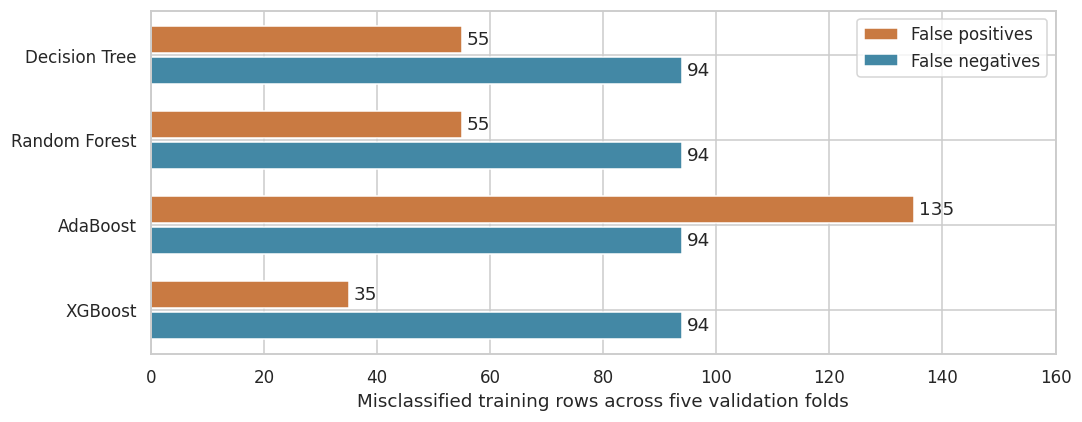

In [14]:
groups = pd.factorize(X_train[selected_dt].fillna("unknown").apply(tuple, axis=1))[0]
group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
group_rows, group_predictions, fold_rows = [], [], []
for fold, (fit_ids, valid_ids) in enumerate(group_cv.split(X_train, y_train, groups), 1):
    assert not set(groups[fit_ids]) & set(groups[valid_ids])
    fold_rows.append({"Fold": fold, "Fit rows": len(fit_ids), "Validation rows": len(valid_ids),
        "Fit groups": len(set(groups[fit_ids])), "Validation groups": len(set(groups[valid_ids])),
        "Validation poisonous": int(y_train.iloc[valid_ids].sum())})
    for name, search in searches.items():
        pipe = clone(search.best_estimator_).fit(X_train.iloc[fit_ids], y_train.iloc[fit_ids])
        probability = pipe.predict_proba(X_train.iloc[valid_ids])[:, 1]
        prediction = pipe.predict(X_train.iloc[valid_ids])
        tn, fp, fn, tp = confusion_matrix(y_train.iloc[valid_ids], prediction, labels=[0,1]).ravel()
        group_rows.append({"Model": name, "Fold": fold, "F1": f1_score(y_train.iloc[valid_ids], prediction, zero_division=0),
            "FN": int(fn), "FP": int(fp), "Selected attributes": ", ".join(pipe.named_steps["select"].selected_)})
        for row_id, actual, pred, prob, group in zip(X_train.index[valid_ids], y_train.iloc[valid_ids], prediction, probability, groups[valid_ids]):
            group_predictions.append({"Model": name, "Fold": fold, "Row ID": int(row_id), "Group": int(group),
                                      "Actual": int(actual), "Predicted": int(pred), "Probability": float(prob)})
    majority = int(y_train.iloc[fit_ids].mean() >= .5)
    for row_id, actual, group in zip(X_train.index[valid_ids], y_train.iloc[valid_ids], groups[valid_ids]):
        group_predictions.append({"Model": "Profile lookup fallback", "Fold": fold, "Row ID": int(row_id),
            "Group": int(group), "Actual": int(actual), "Predicted": majority, "Probability": float(y_train.iloc[fit_ids].mean())})
group_pred = pd.DataFrame(group_predictions)
group_summary_rows = []
for name, frame in group_pred.groupby("Model"):
    assert len(frame) == len(X_train) and frame["Row ID"].nunique() == len(X_train)
    tn, fp, fn, tp = confusion_matrix(frame.Actual, frame.Predicted, labels=[0,1]).ravel()
    group_summary_rows.append({"Model": name, "Accuracy": accuracy_score(frame.Actual, frame.Predicted),
        "Precision": precision_score(frame.Actual, frame.Predicted, zero_division=0),
        "Recall": recall_score(frame.Actual, frame.Predicted, zero_division=0),
        "F1": f1_score(frame.Actual, frame.Predicted), "FN": int(fn), "FP": int(fp)})
group_summary = pd.DataFrame(group_summary_rows)
save_table(group_summary, "group_stress_summary", "Pooled out-of-fold metrics with fixed five-trait groups held apart in training data. Some selected-input profiles remain familiar.")
save_table(pd.DataFrame(fold_rows), "group_fold_support", "Support of the profile-held-apart folds.")
pd.DataFrame(group_rows).to_csv(RESULTS / "group_fold_metrics.csv", index=False)
group_pred.to_csv(RESULTS / "group_predictions.csv", index=False)
display(group_summary)
plot_models = group_summary.set_index("Model").loc[list(searches)]
fig, ax = plt.subplots(figsize=(10, 4))
positions = np.arange(len(plot_models))
fp_bars = ax.barh(positions - .18, plot_models["FP"], height=.32, color="#c97a42", label="False positives")
fn_bars = ax.barh(positions + .18, plot_models["FN"], height=.32, color="#4388a5", label="False negatives")
ax.bar_label(fp_bars, padding=3)
ax.bar_label(fn_bars, padding=3)
ax.set(yticks=positions, yticklabels=plot_models.index,
       xlabel="Misclassified training rows across five validation folds", xlim=(0,160))
ax.invert_yaxis()
ax.legend(loc="upper right")
plt.tight_layout()
save_figure("14_group_stress")


## Decision paths and rare exceptions

The complete fitted Decision Tree gives a checkable explanation of its decisions. For every leaf we export the decoded conditions, class counts in training, and support in the test set. A correct aggregate score can hide leaves that the test never evaluates.


In [15]:
pipe = dt_search.best_estimator_
model = pipe.named_steps["model"]
encoded_names = pipe.named_steps["encode"].get_feature_names_out()
train_leaf = model.apply(pipe[:-1].transform(X_train))
test_leaf = model.apply(pipe[:-1].transform(X_test))
leaf_rows = []
def visit_leaf(node, conditions):
    tree = model.tree_
    if tree.feature[node] < 0:
        a, b = train_leaf == node, test_leaf == node
        leaf_rows.append({"Leaf": node, "Conditions": "; ".join(conditions),
            "Prediction": "poisonous" if model.classes_[np.argmax(tree.value[node])] == 1 else "edible",
            "Train rows": int(a.sum()), "Train poisonous": int(y_train.to_numpy()[a].sum()),
            "Test rows": int(b.sum()), "Test poisonous": int(y_test.to_numpy()[b].sum())})
        return
    attribute, code = encoded_names[tree.feature[node]].rsplit("_", 1)
    condition = attribute + " = " + category_labels[attribute][code]
    visit_leaf(tree.children_left[node], conditions + ["not (" + condition + ")"])
    visit_leaf(tree.children_right[node], conditions + [condition])
visit_leaf(0, [])
leaf_support = pd.DataFrame(leaf_rows)
leaf_support.to_csv(RESULTS / "decision_paths.csv", index=False)
assert leaf_support["Train rows"].sum() == len(X_train)
assert leaf_support["Test rows"].sum() == len(X_test)
display(leaf_support)
# Root missingness is associated with labels, but it is excluded by the selected policies.
root_missing = pd.DataFrame({"Missing root": X_train["stalk-root"].isna(), "Target": y_train}).groupby("Missing root").Target.agg(["size", "sum", "mean"])
root_missing.to_csv(RESULTS / "root_missingness_rates.csv")
assert ((X_raw["ring-number"] == "n") == (X_raw["ring-type"] == "n")).all()
# Retain row IDs and settings so each diagnostic can be independently recalculated.
pd.DataFrame({"Row ID": X_train.index, "Partition": "train"}).to_csv(RESULTS / "training_rows.csv", index=False)
pd.DataFrame({"Row ID": X_test.index, "Partition": "test"}).to_csv(RESULTS / "test_rows.csv", index=False)
policy_rows = []
for name, search in searches.items():
    grid = pd.DataFrame(search.cv_results_)
    for i, params in enumerate(search.cv_results_["params"]):
        policy_rows.append({"Model": name, "Candidate": i, "Attributes permitted": params["select__k"] - len(params.get("select__drop", ())),
            "Pruning": params["select__prune"], "Removed": ", ".join(params.get("select__drop", ())),
            "Mean CV F1": grid.iloc[i]["mean_test_f1"], "CV SD": grid.iloc[i]["std_test_f1"],
            "Selected": i == search.best_index_})
pd.DataFrame(policy_rows).to_csv(RESULTS / "all_policy_comparisons.csv", index=False)


,Leaf,Conditions,Prediction,Train rows,Train poisonous,Test rows,Test poisonous
0,3,not (odor = none); not (odor = almond); not (o...,poisonous,3039,3039,757,757
1,4,not (odor = none); not (odor = almond); odor =...,edible,304,0,96,0
2,5,not (odor = none); odor = almond,edible,328,0,72,0
3,9,odor = none; not (spore-print-color = green); ...,edible,2573,0,627,0
4,11,odor = none; not (spore-print-color = green); ...,edible,114,0,30,0
5,13,odor = none; not (spore-print-color = green); ...,poisonous,8,8,0,0
6,14,odor = none; not (spore-print-color = green); ...,edible,32,0,16,0
7,16,odor = none; not (spore-print-color = green); ...,poisonous,30,30,10,10
8,17,odor = none; not (spore-print-color = green); ...,edible,15,0,1,0
9,18,odor = none; spore-print-color = green,poisonous,56,56,16,16


## Scope and limits

The same test set was evaluated in earlier project versions and is retained for comparison. Final feature policies and hyperparameters are selected using training cross-validation. The test results are not presented as a newly blind confirmation.

These descriptions do not identify individual specimens or species. A random row split can repeat a feature combination across partitions. Grouped validation holds the fixed grouping combinations apart, but some inputs remain familiar under fold-selected traits. It cannot establish transfer to new species. The labels combine poisonous and unknown edibility, as described by UCI. Scores do not establish safe foraging decisions.


In [16]:
cv_ties = tuning_summary.loc[np.isclose(tuning_summary["CV F1"], tuning_summary["CV F1"].max(), atol=1e-12, rtol=0), "Model"].tolist()
run_info = pd.DataFrame({"Item": ["Random state", "Training rows", "Test rows", "CV folds", "Primary metric", "Models tied in CV"],
    "Value": [SEED, len(X_train), len(X_test), 5, "Positive-class F1", ", ".join(cv_ties)]})
run_info.to_csv(RESULTS / "run_info.csv", index=False)
pd.Series(versions).to_csv(RESULTS / "package_versions.csv", header=["Version"])
assert all(np.isfinite(probabilities[n]).all() for n in probabilities)
assert all(len(predictions[n]) == len(y_test) for n in predictions)
print("Checks passed. Figures:", len(list(FIGS.glob("*.pdf"))))
assert X_train.index.intersection(X_test.index).empty
assert all(np.all((probabilities[name] >= 0) & (probabilities[name] <= 1)) for name in probabilities)
assert all(set(np.unique(predictions[name])).issubset({0,1}) for name in predictions)


Checks passed. Figures: 18


## Report exports and checks

Report tables and figures are generated above. The following file provides numeric values used in the report and records the exact selected policy. The report's discussion interprets these exports rather than adding unsupported numerical results.


In [17]:
report_evidence = {"seed": SEED, "training_rows": len(X_train), "test_rows": len(X_test),
    "test_edible": int((y_test == 0).sum()), "test_poisonous": int(y_test.sum()),
    "selected_attributes": selected_dt, "selected_models": selected_policies,
    "probability_quality": probability_quality.to_dict(orient="records"),
    "group_stress": group_summary.to_dict(orient="records"), "baselines": baselines.to_dict(orient="records"),
    "profile_coverage": coverage.to_dict(orient="records"), "conditional_removal": removal.to_dict(orient="records"),
    "decision_paths": leaf_support.to_dict(orient="records")}
(RESULTS / "report_evidence.json").write_text(json.dumps(report_evidence, indent=2, allow_nan=False))
assert all(set(s.best_estimator_.named_steps["select"].selected_) <= set(X_train.columns) for s in searches.values())
assert not set(X_train.index) & set(X_test.index)
assert group_pred.groupby("Model")["Row ID"].nunique().eq(len(X_train)).all()
print("All report exports generated. All consistency checks passed.")


All report exports generated. All consistency checks passed.


## Report presentation tables

These tables format notebook exports for LaTeX without introducing new estimates.


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
RESULTS = Path('results')
def report_table(frame, name, caption):
    frame = frame.rename(columns={
        'Validation rows': 'Rows',
        'Rows with seen selected profiles': 'Seen profiles',
        'Rows with unseen levels': 'New levels',
        'Errors with unseen levels': 'Errors, new levels',
        'Errors with seen levels': 'Errors, seen levels',
        'Mean profile accuracy': 'Profile accuracy',
        'Mean positive profile recall': 'Positive recall',
        'Mean edible profile specificity': 'Edible specificity',
        'Rows in mixed profiles': 'Mixed rows',
        'Minimum training errors': 'Min. training errors',
        'Best mean F1': 'Best F1',
        'Worst mean F1': 'Worst F1',
        'Configurations': 'Settings',
        'Perfect mean F1 configurations': 'Perfect F1 settings',
    })
    text = frame.to_latex(index=False, escape=True, float_format=('%.6f' if 'probability' in name else '%.4f'), caption=caption.replace('_', r'\_'), position='H')
    text = text.replace('\\begin{tabular}', '\\begin{adjustbox}{max width=\\linewidth}\\begin{tabular}').replace('\\end{tabular}', '\\end{tabular}\\end{adjustbox}')
    text = text.replace('\\begin{table}[H]', '\\begin{table}[H]\n\\centering\\small')
    (RESULTS / (name + '.tex')).write_text(text)
report_table(pd.read_csv(RESULTS/'group_stress_summary.csv'), 'report_group_stress', 'Stress test with fixed five-trait groups held apart. Metrics pool five validation folds of training rows.')
report_table(pd.read_csv(RESULTS/'probability_quality.csv').iloc[:, :3], 'report_probability', 'Test-set probability quality. Smaller losses are better.')
coverage_table = pd.read_csv(RESULTS/'profile_coverage.csv').rename(columns={'Training profiles':'Train profiles', 'Test rows seen in training':'Seen test rows', 'Training mixed-label profiles':'Mixed profiles'})
report_table(coverage_table, 'report_coverage', 'Exact predictor-profile coverage. Test size is 1,625 rows.')
report_table(pd.read_csv(RESULTS/'model_complexity.csv'), 'report_complexity', 'Complexity of the fitted models.')
report_table(pd.read_csv(RESULTS/'decision_paths.csv').drop(columns=['Conditions']), 'report_leaves', 'Decision Tree leaf support. Complete conditions are exported in decision_paths.csv.')
report_table(pd.read_csv(RESULTS/'test_metrics.csv'), 'report_test_metrics', 'Classification and ranking on the previously evaluated test set.')
report_table(pd.read_csv(RESULTS/'baselines.csv'), 'report_baselines', 'Predefined test-set baselines. Poisonous is positive.')


report_table(pd.read_csv(RESULTS/"group_fold_support.csv"), "report_group_fold_support", "Support of the profile-held-apart validation folds.")


## Sensitivity within the selected feature policy

Hold the feature policy fixed to see which model settings reach the validation ceiling.


In [19]:
# Keep comparisons at the selected feature policy so model parameters are not confounded with different attributes.
selected = json.loads((RESULTS/'selected_models.json').read_text())
policy_best_rows=[]
for item in selected:
    grid=pd.read_csv(RESULTS/(item['Model'].lower().replace(' ','_')+'_grid.csv'))
    params=item['Parameters']; mask=np.ones(len(grid),dtype=bool)
    for key in ['select__k','select__prune','select__drop']:
        if key in params:
            if key=='select__drop':
                mask &= grid['param_'+key].fillna('()').eq(str(tuple(params[key])))
            else: mask &= grid['param_'+key].eq(params[key])
        elif 'param_'+key in grid:
            mask &= grid['param_'+key].isna()
    columns=[c for c in grid if c.startswith('param_model__')]+['mean_train_f1','mean_test_f1','std_test_f1']
    table=grid.loc[mask,columns]
    assert len(table)>0
    table.to_csv(RESULTS/(item['Model'].lower().replace(' ','_')+'_selected_policy_grid.csv'),index=False)
    policy_best_rows.append({'Model':item['Model'],'Best mean F1':table.mean_test_f1.max(),
        'Worst mean F1':table.mean_test_f1.min(),'Configurations':len(table),
        'Perfect mean F1 configurations':int(np.isclose(table.mean_test_f1,1,atol=1e-12,rtol=0).sum())})
policy_ranges=pd.DataFrame(policy_best_rows)
report_table(policy_ranges,'selected_policy_ranges','Sensitivity to model settings within each selected feature policy.')
policy_ranges.to_csv(RESULTS/'selected_policy_ranges.csv',index=False)



## Check saved stress predictions

Recalculate pooled metrics and ensure each profile belongs to one validation fold.


In [20]:
# Independently recalculate pooled stress metrics from saved predictions.
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score,confusion_matrix
stress_predictions=pd.read_csv(RESULTS/'group_predictions.csv')
summary=pd.read_csv(RESULTS/'group_stress_summary.csv').set_index('Model')
for name, frame in stress_predictions.groupby('Model'):
    assert frame['Row ID'].nunique()==6499 and len(frame)==6499
    assert np.isclose(f1_score(frame.Actual,frame.Predicted), summary.loc[name,'F1'])
    assert np.isclose(accuracy_score(frame.Actual,frame.Predicted),summary.loc[name,'Accuracy'])
    group_folds=frame.groupby('Group').Fold.nunique()
    assert group_folds.eq(1).all()

stress_predictions['Odor']=X_raw.loc[stress_predictions['Row ID'],'odor'].map(category_labels['odor']).to_numpy()
assert np.array_equal(y.loc[stress_predictions['Row ID']].to_numpy(),stress_predictions.Actual.to_numpy())
stress_predictions['FN']=((stress_predictions.Actual==1)&(stress_predictions.Predicted==0)).astype(int)
stress_predictions['FP']=((stress_predictions.Actual==0)&(stress_predictions.Predicted==1)).astype(int)
stress_subgroups=stress_predictions.groupby(['Model','Odor']).agg(Rows=('Actual','size'),Poisonous=('Actual','sum'),FN=('FN','sum'),FP=('FP','sum')).reset_index()
stress_subgroups.to_csv(RESULTS/'group_odor_subgroups.csv',index=False)
display(stress_subgroups.loc[(stress_subgroups.FN+stress_subgroups.FP>0)&(stress_subgroups.Model!='Profile lookup fallback')])
profile_rows=[]
probability_strata=[]
for name,frame in stress_predictions.groupby('Model'):
    actual_profiles=[]
    for group,profile in frame.groupby('Group'):
        assert profile.Actual.nunique()==1
        actual_profiles.append({'Group':group,'Actual':int(profile.Actual.iloc[0]),'Accuracy':float((profile.Actual==profile.Predicted).mean())})
    actual_profiles=pd.DataFrame(actual_profiles)
    profile_rows.append({'Model':name,'Mean profile accuracy':actual_profiles.Accuracy.mean(),
        'Mean positive profile recall':actual_profiles.loc[actual_profiles.Actual==1,'Accuracy'].mean(),
        'Mean edible profile specificity':actual_profiles.loc[actual_profiles.Actual==0,'Accuracy'].mean(),
        'Positive profiles':int((actual_profiles.Actual==1).sum()),'Edible profiles':int((actual_profiles.Actual==0).sum())})
    extreme=frame.Probability.isin([0.,1.])
    wrong=frame.Actual!=frame.Predicted
    probability_strata.append({'Model':name,'Extreme probability rows':int(extreme.sum()),'Errors at extreme probabilities':int((extreme&wrong).sum()),'Other errors':int((~extreme&wrong).sum())})
profile_balanced=pd.DataFrame(profile_rows)
profile_balanced.to_csv(RESULTS/'group_profile_balanced_summary.csv',index=False)
report_table(profile_balanced,'report_profile_balanced','Equal-profile diagnostic averages. These are different weights from the pooled row metrics.')
pd.DataFrame(probability_strata).to_csv(RESULTS/'group_probability_extremes.csv',index=False)
display(profile_balanced)


,Model,Odor,Rows,Poisonous,FN,FP
0,AdaBoost,almond,328,0,0,119
6,AdaBoost,none,2828,94,94,16
9,Decision Tree,almond,328,0,0,39
15,Decision Tree,none,2828,94,94,16
27,Random Forest,almond,328,0,0,39
33,Random Forest,none,2828,94,94,16
36,XGBoost,almond,328,0,0,19
42,XGBoost,none,2828,94,94,16


,Model,Mean profile accuracy,Mean positive profile recall,Mean edible profile specificity,Positive profiles,Edible profiles
0,AdaBoost,0.829787,0.823529,0.833333,17,30
1,Decision Tree,0.872340,0.823529,0.900000,17,30
2,Profile lookup fallback,0.638298,0.000000,1.000000,17,30
3,Random Forest,0.872340,0.823529,0.900000,17,30
4,XGBoost,0.893617,0.823529,0.933333,17,30


## Where grouped-validation errors occur

Decode erroneous profiles and distinguish new category levels from new combinations.


In [21]:
# Export error concentrations in decoded profiles and category novelty under the specified stress folds.
group_profiles=[];novelty_rows=[]
training=pd.read_csv(RESULTS/'training_rows.csv')['Row ID'].to_numpy()
fold_choices=pd.read_csv(RESULTS/'group_fold_metrics.csv').set_index(['Model','Fold'])
for name, frame in stress_predictions.groupby('Model'):
    if name=='Profile lookup fallback': continue
    for fold, validation in frame.groupby('Fold'):
        attrs=fold_choices.loc[(name,fold),'Selected attributes'].split(', ')
        fit_ids=np.setdiff1d(training,validation['Row ID'].to_numpy())
        valid_ids=validation['Row ID'].to_numpy()
        novel=np.zeros(len(valid_ids),dtype=bool)
        novel_traits=[]
        for attribute in attrs:
            known=set(X_raw.loc[fit_ids,attribute].fillna('unknown'))
            absent=~X_raw.loc[valid_ids,attribute].fillna('unknown').isin(known).to_numpy()
            novel|=absent
            if absent.any():novel_traits.append(attribute)
        fit_profiles=X_raw.loc[fit_ids,attrs].fillna('unknown').apply(tuple,axis=1)
        validation_profiles=X_raw.loc[valid_ids,attrs].fillna('unknown').apply(tuple,axis=1)
        seen_profiles=validation_profiles.isin(set(fit_profiles)).to_numpy()
        incorrect=validation.Actual.to_numpy()!=validation.Predicted.to_numpy()
        novelty_rows.append({'Model':name,'Fold':fold,'Validation rows':len(valid_ids),
            'Rows with seen selected profiles':int(seen_profiles.sum()),'Rows with unseen levels':int(novel.sum()),'Errors with unseen levels':int((incorrect&novel).sum()),
            'Errors with seen levels':int((incorrect&~novel).sum()),'Traits with unseen levels':', '.join(novel_traits)})
    for group, rows in frame.groupby('Group'):
        wrong=rows.Actual!=rows.Predicted
        if wrong.any():
            row=X_raw.loc[int(rows.iloc[0]['Row ID'])]
            description='; '.join(c+'='+category_labels[c][row[c]] for c in selected_dt)
            group_profiles.append({'Model':name,'Group':int(group),'Profile':description,'Rows':len(rows),
                'FN':int(((rows.Actual==1)&(rows.Predicted==0)).sum()),
                'FP':int(((rows.Actual==0)&(rows.Predicted==1)).sum())})
pd.DataFrame(group_profiles).to_csv(RESULTS/'group_error_profiles.csv',index=False)
novelty=pd.DataFrame(novelty_rows)
novelty.to_csv(RESULTS/'group_category_novelty.csv',index=False)
novelty_summary=novelty.groupby('Model')[['Validation rows','Rows with seen selected profiles','Rows with unseen levels','Errors with unseen levels','Errors with seen levels']].sum().reset_index()
report_table(novelty_summary,'report_group_novelty','Stress-test errors with and without new category levels in selected attributes.')
novelty_summary.to_csv(RESULTS/'group_category_novelty_summary.csv',index=False)
display(policy_ranges)
display(novelty_summary)
print('Saved-prediction checks passed.')


Saved-prediction checks passed.


,Model,Best mean F1,Worst mean F1,Configurations,Perfect mean F1 configurations
0,Decision Tree,1.0,0.996333,6,4
1,Random Forest,1.0,0.992751,16,12
2,AdaBoost,1.0,0.968967,12,4
3,XGBoost,1.0,0.993895,8,4


,Model,Validation rows,Rows with seen selected profiles,Rows with unseen levels,Errors with unseen levels,Errors with seen levels
0,AdaBoost,6499,981,1276,56,173
1,Decision Tree,6499,981,1276,56,93
2,Random Forest,6499,981,1276,56,93
3,XGBoost,6499,981,1276,56,73


## Grid values and odor support

Record the searched model values and the odor exceptions in each partition.


In [22]:
axes_rows=[]
for item in selected:
    grid=pd.read_csv(RESULTS/(item['Model'].lower().replace(' ','_')+'_grid.csv'))
    for c in grid.columns:
        if c.startswith('param_model__'):
            values=grid[c].drop_duplicates().tolist()
            display_values=['None (unlimited)' if pd.isna(value) else str(value) for value in values]
            axes_rows.append({'Model':item['Model'],'Parameter':c.replace('param_model__','').replace('estimator__','weak tree ').replace('_',' '),'Values':', '.join(display_values)})
axes_table=pd.DataFrame(axes_rows)
axes_table.to_csv(RESULTS/'model_grid_axes.csv',index=False)
report_table(axes_table,'report_grid_axes','Model parameter values tested. Feature-policy choices are described separately.')

odor_exception_rows=[]
for partition, data, labels in [('train',X_train,y_train),('test',X_test,y_test)]:
    for category, indices in data.groupby('odor').groups.items():
        class_labels=labels.loc[indices]
        odor_exception_rows.append({'Partition':partition,'Odor':category_labels['odor'][category],
            'Rows':len(indices),'Edible':int((class_labels==0).sum()),'Poisonous':int((class_labels==1).sum())})
pd.DataFrame(odor_exception_rows).to_csv(RESULTS/'odor_partition_counts.csv',index=False)
print('Model grid axes and odor-exception support exported.')


Model grid axes and odor-exception support exported.


## Source metadata

Keep the source declarations alongside observed category counts.


In [23]:
mushroom.variables.to_csv(RESULTS/'uci_variable_metadata.csv',index=False)
(RESULTS/'uci_dataset_metadata.json').write_text(json.dumps(mushroom.metadata,indent=2,default=str))
print('API cap-color type:',mushroom.variables.loc[mushroom.variables.name=='cap-color','type'].iloc[0])
print('Observed cap-color levels:',X_raw['cap-color'].nunique())


API cap-color type: Binary
Observed cap-color levels: 10


## Probability mechanisms under profile shift

Check the AdaBoost margin transformation and compare stress-test probability losses.


In [24]:
from scipy.special import expit
from sklearn.metrics import brier_score_loss, log_loss
ada_pipe=searches['AdaBoost'].best_estimator_
ada_margin=ada_pipe.decision_function(X_test)
ada_probability=ada_pipe.predict_proba(X_test)[:,1]
assert np.allclose(expit(ada_margin),ada_probability,rtol=0,atol=1e-12)
ada_margin_table=pd.DataFrame({'Row ID':X_test.index,'Actual':y_test.to_numpy(),'Weighted vote margin':ada_margin,'Poisonous probability':ada_probability})
ada_margin_table.to_csv(RESULTS/'adaboost_margin_probabilities.csv',index=False)
ada_margin_table.groupby('Actual')[['Weighted vote margin','Poisonous probability']].agg(['min','mean','max']).to_csv(RESULTS/'adaboost_margin_summary.csv')
group_probability_rows=[]
for name,frame in stress_predictions.groupby('Model'):
    group_probability_rows.append({'Model':name,'Brier':brier_score_loss(frame.Actual,frame.Probability),'Log loss':log_loss(frame.Actual,frame.Probability)})
group_probability=pd.DataFrame(group_probability_rows)
group_probability.to_csv(RESULTS/'group_probability_quality.csv',index=False)
report_table(group_probability,'report_group_probability','Probability quality with fixed five-trait groups held apart, pooled across five folds.')
display(group_probability)


,Model,Brier,Log loss
0,AdaBoost,0.160706,0.511020
1,Decision Tree,0.021321,0.739816
2,Profile lookup fallback,0.254681,0.702578
3,Random Forest,0.020999,0.403861
4,XGBoost,0.017483,0.170708


## Focused explanatory figures

Show class counts and the specific predictor relationships discussed in the report.


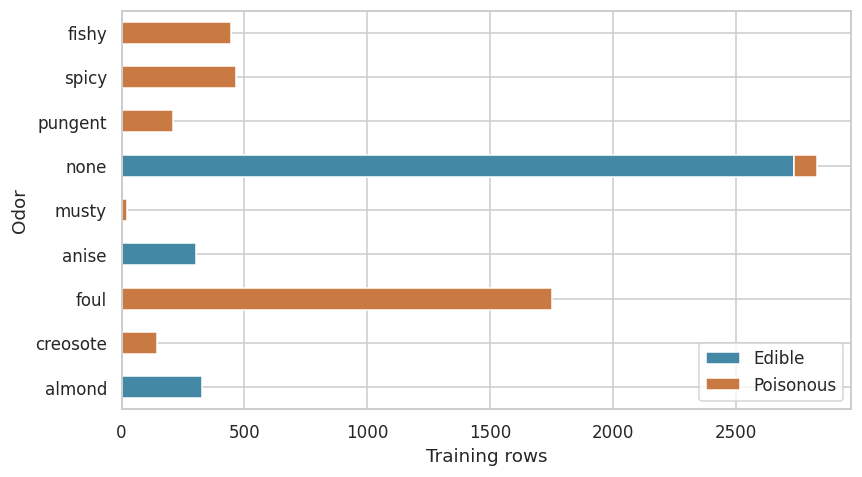

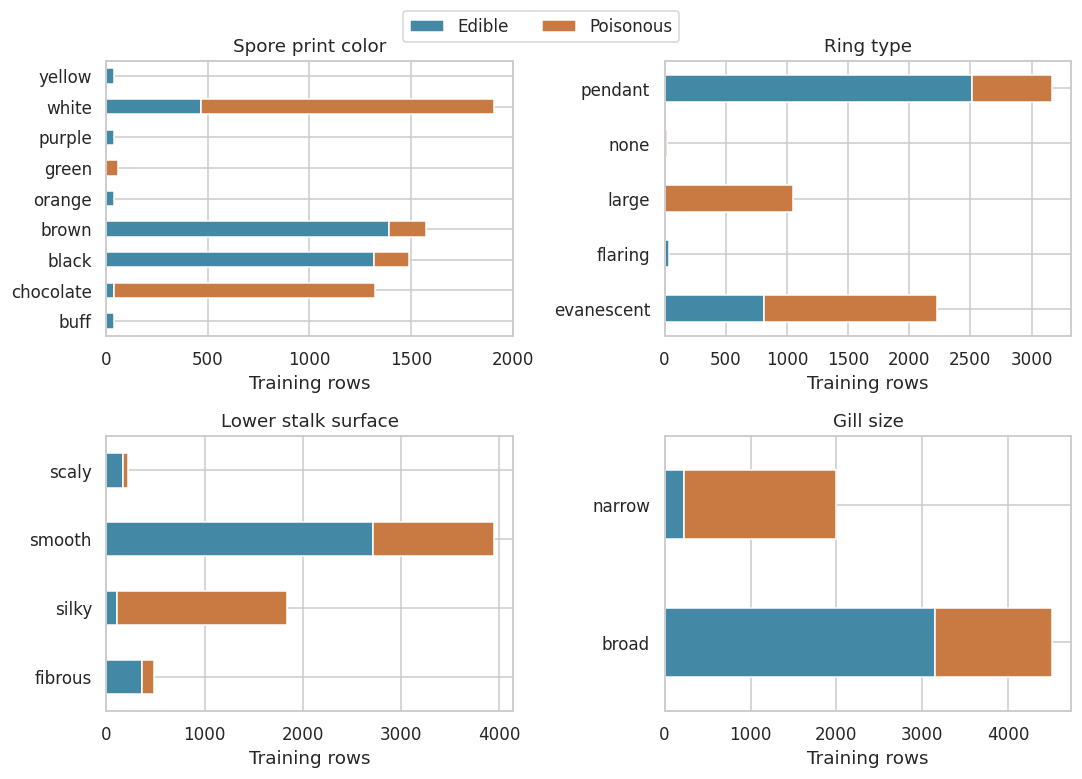

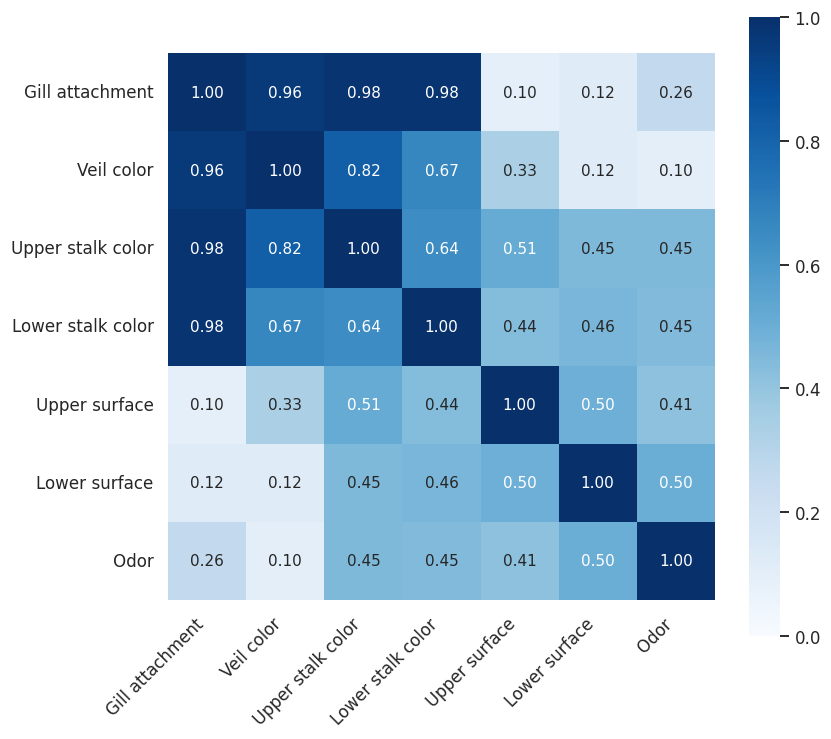

In [25]:
fig, ax=plt.subplots(figsize=(8,4.5))
odor_counts=pd.crosstab(X_train.odor,y_train).rename(index=category_labels['odor'],columns={0:'Edible',1:'Poisonous'})
odor_counts.plot.barh(stacked=True,ax=ax,color=['#4388a5','#c97a42'])
ax.set(xlabel='Training rows',ylabel='Odor')
ax.legend(loc='lower right')
plt.tight_layout()
save_figure('15_odor_class_counts')
other_traits=[a for a in selected_dt if a!='odor']
fig,axes=plt.subplots(2,2,figsize=(10,7))
for attribute,ax in zip(other_traits,axes.flat):
    counts=pd.crosstab(X_train[attribute],y_train).rename(index=category_labels[attribute],columns={0:'Edible',1:'Poisonous'})
    counts.plot.barh(stacked=True,ax=ax,legend=False,color=['#4388a5','#c97a42'])
    ax.set(title=attribute.replace('stalk-surface-below-ring','Lower stalk surface').replace('spore-print-color','Spore print color').replace('ring-type','Ring type').replace('gill-size','Gill size'),xlabel='Training rows',ylabel='')
fig.legend(['Edible','Poisonous'],loc='upper center',ncol=2,bbox_to_anchor=(.5,1.02))
plt.tight_layout()
save_figure('16_selected_trait_counts')
association=pd.read_csv(RESULTS/'attribute_associations.csv',index_col=0)
focus=['gill-attachment','veil-color','stalk-color-above-ring','stalk-color-below-ring','stalk-surface-above-ring','stalk-surface-below-ring','odor']
short=['Gill attachment','Veil color','Upper stalk color','Lower stalk color','Upper surface','Lower surface','Odor']
focused=association.loc[focus,focus].copy();focused.index=short;focused.columns=short
fig,ax=plt.subplots(figsize=(8,7))
sns.heatmap(focused,annot=True,fmt='.2f',vmin=0,vmax=1,cmap='Blues',square=True,ax=ax,annot_kws={'fontsize':10})
ax.tick_params(axis='x',labelrotation=45)
plt.setp(ax.get_xticklabels(),ha='right')
plt.tight_layout()
save_figure('17_focused_associations')



## What feature removal makes indistinguishable

Count contradictory training profiles and the minimum number of training errors forced by each reduced representation.


In [26]:
profile_conflicts=[]
for removed in [None]+selected_dt:
    attributes=[a for a in selected_dt if a!=removed]
    profiles=X_train[attributes].fillna('unknown').apply(tuple,axis=1)
    counts=pd.DataFrame({'Profile':profiles.to_numpy(),'Target':y_train.to_numpy()}).groupby('Profile').Target.agg(['size','nunique','sum'])
    profile_conflicts.append({'Removed':removed or 'None','Attributes':len(attributes),'Profiles':len(counts),
        'Mixed-label profiles':int((counts['nunique']>1).sum()),'Rows in mixed profiles':int(counts.loc[counts['nunique']>1,'size'].sum()),'Minimum training errors':int(np.minimum(counts['sum'],counts['size']-counts['sum']).sum())})
conflicts=pd.DataFrame(profile_conflicts)
conflicts.to_csv(RESULTS/'conditional_profile_conflicts.csv',index=False)
report_table(conflicts,'report_profile_conflicts','Training profiles with contradictory labels after removal from the selected policy.')
display(conflicts)


,Removed,Attributes,Profiles,Mixed-label profiles,Rows in mixed profiles,Minimum training errors
0,None,5,47,0,0,0
1,odor,4,29,3,1181,129
2,spore-print-color,4,28,2,1817,64
3,ring-type,4,43,1,24,8
4,stalk-surface-below-ring,4,33,1,62,30
5,gill-size,4,41,1,153,8


## Refit verification

A second fit of each selected pipeline must reproduce its predictions and all four metrics in every original validation fold. Timing and rendering metadata are outside this numerical check.


In [27]:
verification=[]
row_cv_coverage=[]
from sklearn.base import clone
for name, search in searches.items():
    refit=clone(search.best_estimator_).fit(X_train,y_train)
    predicted=refit.predict(X_test)
    probability=refit.predict_proba(X_test)[:,1]
    assert np.array_equal(predicted,predictions[name])
    delta=float(np.max(np.abs(probability-probabilities[name])))
    assert delta < 1e-7
    folds=cross_validate(clone(refit),X_train,y_train,cv=cv,scoring=scores,error_score='raise',return_estimator=True)
    for fold, ((fit_ids,valid_ids), fold_pipe) in enumerate(zip(cv.split(X_train,y_train),folds['estimator']),1):
        attrs=fold_pipe.named_steps['select'].selected_
        fit_keys=X_train.iloc[fit_ids][attrs].fillna('unknown').apply(tuple,axis=1)
        valid_keys=X_train.iloc[valid_ids][attrs].fillna('unknown').apply(tuple,axis=1)
        row_cv_coverage.append({'Model':name,'Fold':fold,'Validation rows':len(valid_ids),'Validation rows with seen profiles':int(valid_keys.isin(set(fit_keys)).sum()),'Attributes':', '.join(attrs)})
    for metric in scores:
        expected=np.array([search.cv_results_[f'split{i}_test_{metric}'][search.best_index_] for i in range(5)])
        assert np.allclose(folds['test_'+metric],expected,atol=1e-12,rtol=0)
    verification.append({'Model':name,'Predictions match':True,'Maximum probability difference':delta,'Selected CV folds match':True})
pd.DataFrame(row_cv_coverage).to_csv(RESULTS/'row_cv_profile_coverage.csv',index=False)
pd.DataFrame(verification).to_csv(RESULTS/'reproducibility_checks.csv',index=False)
display(pd.DataFrame(verification))
print('Independent selected-model refits and all selected fold metrics match.')


Independent selected-model refits and all selected fold metrics match.


,Model,Predictions match,Maximum probability difference,Selected CV folds match
0,Decision Tree,True,0.0,True
1,Random Forest,True,0.0,True
2,AdaBoost,True,0.0,True
3,XGBoost,True,0.0,True


In [28]:
evidence = json.loads((RESULTS / "report_evidence.json").read_text())
for key, filename in {
    "scaling_summary": "scaling_summary.csv",
    "model_complexity": "model_complexity.csv",
    "group_probability_quality": "group_probability_quality.csv",
    "conditional_profile_conflicts": "conditional_profile_conflicts.csv",
    "group_profile_balanced": "group_profile_balanced_summary.csv",
    "group_category_novelty": "group_category_novelty_summary.csv",
    "selected_policy_ranges": "selected_policy_ranges.csv",
    "group_fold_support": "group_fold_support.csv",
    "row_cv_profile_coverage": "row_cv_profile_coverage.csv",
    "reproducibility_checks": "reproducibility_checks.csv",
}.items():
    evidence[key] = pd.read_csv(RESULTS / filename, keep_default_na=False).to_dict(orient="records")
(RESULTS / "report_evidence.json").write_text(json.dumps(evidence, indent=2, allow_nan=False))
cache.cleanup()
